## Table of Contents

1. [Introduction & Research Question](#1-introduction--research-question)
2. [Data Loading & Initial Inspection](#2-data-loading--initial-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Feature Engineering](#5-feature-engineering)
6. [Baseline Model (Logistic Regression)](#6-baseline-model-logistic-regression)
7. [Findings & Next Steps](#7-findings--next-steps)
8. [Temporal Split Design & Population Rules](#8-temporal-split-design--population-rules)
9. [Baseline Models](#9-baseline-models)
   - 9.1 Popularity Baseline (Recommendations)
   - 9.2 Seasonal Naïve Baseline (Forecasting)
10. [Customer Behavior Features (Leakage-Safe)](#10-customer-behavior-features-leakage-safe)
11. [Weekly Category Forecast Dataset](#11-weekly-category-forecast-dataset)
12. [Customer Segmentation (K-Means, K=4)](#12-customer-segmentation-k-means-k4)
13. [Demand Forecast Models](#13-demand-forecast-models)
    - 13.1 Linear Regression
    - 13.2 Random Forest
    - 13.3 XGBoost
    - 13.4 Model Comparison
14. [Recommendation System](#14-recommendation-system)
    - 14.1 Interaction Split
    - 14.2 Segment-Based Recommender
    - 14.3 Item-Item Collaborative Filtering
    - 14.4 Model Comparison
    - 14.5 Hybrid Recommender (CF + Content)
    - 14.6 Full Evaluation & Cohort Analysis
    - 14.7 Artifact Export
15. [Governance & Model Cards](#15-governance--model-cards)
    - 15.1 Data Lineage
    - 15.2 Model Cards (RF Forecaster, K-Means Segmentation, CF/Hybrid Recommender)
    - 15.3 Responsible AI Review
16. [Project Retrospective](#16-project-retrospective)
    - 16.1 Gate Scorecard
    - 16.2 Lessons Learned
    - 16.3 Backlog & Future Work
    - 16.4 Decision Log


## 1. Introduction & Research Question

**Research Question:** Can historical customer transactions, product attributes, and customer metadata be leveraged to build a retail intelligence system that segments customers into actionable groups, forecasts category-level demand, and generates personalized product recommendations?

**Dataset:** H&M Personalized Fashion Recommendations (Kaggle)  
- `articles.csv` — Product metadata (105K+ articles)
- `customers.csv` — Customer demographics (~1.37M customers)
- `transactions_train.csv` — Purchase history (~31.8M transactions, Sep 2018 – Sep 2020; **filtered to last 12 months** for this analysis: ~15M transactions, Sep 2019 – Sep 2020)

**Why this matters:** Retailers must balance demand anticipation with personalized product discovery. Simple popularity rules over-recommend a narrow product set, while aggregate forecasts ignore individual customer behavior. A unified analytical approach combining segmentation, forecasting, and recommendation provides actionable decision support for inventory planning and marketing.

**Scope note:** We focus on the most recent 12 months of transactions to keep memory usage manageable (~1.5 GB vs ~3.3 GB) while retaining the most behaviorally relevant purchase patterns and ~996K active customers.

## 2. Data Loading & Initial Inspection

In [1]:
#%pip install xgboost

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load datasets
DATA_PATH = '../Data/'

articles = pd.read_csv(DATA_PATH + 'articles.csv')
customers = pd.read_csv(DATA_PATH + 'customers.csv')
transactions = pd.read_csv(DATA_PATH + 'transactions_train.csv', parse_dates=['t_dat'])

# Filter to most recent year (Sep 2019 â€“ Sep 2020) to reduce memory footprint
# Full dataset spans Sep 2018 â€“ Sep 2020; keeping last 12 months retains
# the most relevant purchasing behavior while cutting ~53% of rows
print(f'Transactions loaded: {transactions.shape[0]:,} rows')
transactions = transactions[transactions['t_dat'] >= '2019-09-20'].reset_index(drop=True)
print(f'After filtering to last 12 months (Sep 2019 â€“ Sep 2020): {transactions.shape[0]:,} rows')

print(f'\nArticles:      {articles.shape[0]:>12,} rows x {articles.shape[1]} columns')
print(f'Customers:     {customers.shape[0]:>12,} rows x {customers.shape[1]} columns')
print(f'Transactions:  {transactions.shape[0]:>12,} rows x {transactions.shape[1]} columns')

Transactions loaded: 31,788,324 rows
After filtering to last 12 months (Sep 2019 â€“ Sep 2020): 14,984,423 rows

Articles:           105,542 rows x 25 columns
Customers:        1,371,980 rows x 7 columns
Transactions:    14,984,423 rows x 5 columns


In [4]:
# Inspect articles
print('=== ARTICLES ===')
print(f'\nShape: {articles.shape}')
print(f'\nData types:')
print(articles.dtypes)
print(f'\nFirst 3 rows:')
articles.head(3)

=== ARTICLES ===

Shape: (105542, 25)

Data types:
article_id                      int64
product_code                    int64
prod_name                         str
product_type_no                 int64
product_type_name                 str
product_group_name                str
graphical_appearance_no         int64
graphical_appearance_name         str
colour_group_code               int64
colour_group_name                 str
perceived_colour_value_id       int64
perceived_colour_value_name       str
perceived_colour_master_id      int64
perceived_colour_master_name      str
department_no                   int64
department_name                   str
index_code                        str
index_name                        str
index_group_no                  int64
index_group_name                  str
section_no                      int64
section_name                      str
garment_group_no                int64
garment_group_name                str
detail_desc                       str

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


In [5]:
# Inspect customers
print('=== CUSTOMERS ===')
print(f'\nShape: {customers.shape}')
print(f'\nData types:')
print(customers.dtypes)
print(f'\nFirst 3 rows:')
customers.head(3)

=== CUSTOMERS ===

Shape: (1371980, 7)

Data types:
customer_id                   str
FN                        float64
Active                    float64
club_member_status            str
fashion_news_frequency        str
age                       float64
postal_code                   str
dtype: object

First 3 rows:


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...


In [6]:
# Inspect transactions
print('=== TRANSACTIONS ===')
print(f'\nShape: {transactions.shape}')
print(f'\nData types:')
print(transactions.dtypes)
print(f'\nDate range: {transactions["t_dat"].min()} to {transactions["t_dat"].max()}')
print(f'\nFirst 3 rows:')
transactions.head(3)

=== TRANSACTIONS ===

Shape: (14984423, 5)

Data types:
t_dat               datetime64[us]
customer_id                    str
article_id                   int64
price                      float64
sales_channel_id             int64
dtype: object

Date range: 2019-09-20 00:00:00 to 2020-09-22 00:00:00

First 3 rows:


,t_dat,customer_id,article_id,price,sales_channel_id
0,2019-09-20,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,745014003,0.020322,2
1,2019-09-20,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,812484002,0.054220,2
2,2019-09-20,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,733098013,0.003373,2


In [7]:
# Summary statistics for numeric columns
print('=== ARTICLES - Numeric Summary ===')
display(articles.describe())

print('\n=== CUSTOMERS - Numeric Summary ===')
display(customers.describe())

print('\n=== TRANSACTIONS - Numeric Summary ===')
display(transactions.describe())

=== ARTICLES - Numeric Summary ===


,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no
count,1.055420e+05,105542.000000,105542.000000,1.055420e+05,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000
mean,6.984246e+08,698424.563378,234.861875,1.009515e+06,32.233822,3.206183,7.807972,4532.777833,3.171534,42.664219,1010.438290
std,1.284624e+08,128462.384432,75.049308,2.241359e+04,28.086154,1.563839,5.376727,2712.692011,4.353234,23.260105,6.731023
min,1.087750e+08,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000
25%,6.169925e+08,616992.500000,252.000000,1.010008e+06,9.000000,2.000000,4.000000,1676.000000,1.000000,20.000000,1005.000000
50%,7.022130e+08,702213.000000,259.000000,1.010016e+06,14.000000,4.000000,5.000000,4222.000000,2.000000,46.000000,1009.000000
75%,7.967030e+08,796703.000000,272.000000,1.010016e+06,52.000000,4.000000,11.000000,7389.000000,4.000000,61.000000,1017.000000
max,9.594610e+08,959461.000000,762.000000,1.010029e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000



=== CUSTOMERS - Numeric Summary ===


,FN,Active,age
count,476930.0,464404.0,1.356119e+06
mean,1.0,1.0,3.638696e+01
std,0.0,0.0,1.431363e+01
min,1.0,1.0,1.600000e+01
25%,1.0,1.0,2.400000e+01
50%,1.0,1.0,3.200000e+01
75%,1.0,1.0,4.900000e+01
max,1.0,1.0,9.900000e+01



=== TRANSACTIONS - Numeric Summary ===


,t_dat,article_id,price,sales_channel_id
count,14984423,1.498442e+07,1.498442e+07,1.498442e+07
mean,2020-03-27 20:00:01.550088,7.531170e+08,2.823860e-02,1.717797e+00
min,2019-09-20 00:00:00,1.087750e+08,1.694915e-05,1.000000e+00
25%,2019-12-23 00:00:00,7.071350e+08,1.693220e-02,1.000000e+00
50%,2020-04-08 00:00:00,7.874810e+08,2.540678e-02,2.000000e+00
75%,2020-06-25 00:00:00,8.366990e+08,3.388136e-02,2.000000e+00
max,2020-09-22 00:00:00,9.562170e+08,5.067797e-01,2.000000e+00
std,NaN,1.295376e+08,1.901558e-02,4.500719e-01


## 3. Data Cleaning

### 3.1 Missing Values Analysis

In [8]:
# Check missing values across all datasets
def missing_summary(df, name):
    """Summarize missing values for a dataframe."""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct.round(2)
    })
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    if len(summary) == 0:
        print(f'\n{name}: No missing values found.')
    else:
        print(f'\n{name}: Missing Values')
        display(summary)
    return summary

miss_articles = missing_summary(articles, 'Articles')
miss_customers = missing_summary(customers, 'Customers')
miss_transactions = missing_summary(transactions, 'Transactions')


Articles: Missing Values


,Missing Count,Missing %
detail_desc,416,0.39



Customers: Missing Values


,Missing Count,Missing %
Active,907576,66.15
FN,895050,65.24
fashion_news_frequency,16011,1.17
age,15861,1.16
club_member_status,6062,0.44



Transactions: No missing values found.


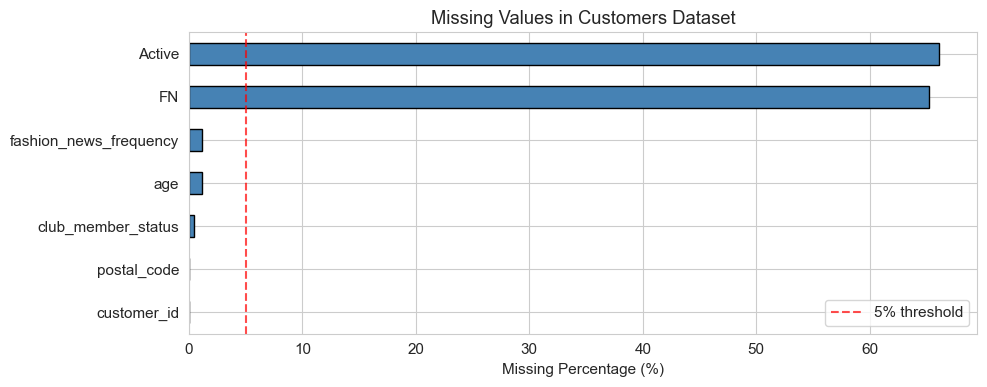

In [9]:
# Visualize missing values in customers (the dataset with most missing data)
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = (customers.isnull().sum() / len(customers) * 100).sort_values(ascending=True)
missing_pct.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values in Customers Dataset')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Handle missing values in customers
print('Customers missing value treatment:')
print(f'  FN: {customers["FN"].isnull().sum():,} missing -> fill with 0 (not subscribed)')
print(f'  Active: {customers["Active"].isnull().sum():,} missing -> fill with 0 (inactive)')
print(f'  club_member_status: {customers["club_member_status"].isnull().sum():,} missing -> fill with "UNKNOWN"')
print(f'  fashion_news_frequency: {customers["fashion_news_frequency"].isnull().sum():,} missing -> fill with "NONE"')
print(f'  age: {customers["age"].isnull().sum():,} missing -> fill with median age')

customers['FN'] = customers['FN'].fillna(0).astype(int)
customers['Active'] = customers['Active'].fillna(0).astype(int)
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')
customers['age'] = customers['age'].fillna(customers['age'].median())

# Handle missing detail_desc in articles
articles['detail_desc'] = articles['detail_desc'].fillna('No description')

print('\nAfter treatment:')
print(f'  Customers remaining nulls: {customers.isnull().sum().sum()}')
print(f'  Articles remaining nulls: {articles.isnull().sum().sum()}')

Customers missing value treatment:
  FN: 895,050 missing -> fill with 0 (not subscribed)
  Active: 907,576 missing -> fill with 0 (inactive)
  club_member_status: 6,062 missing -> fill with "UNKNOWN"
  fashion_news_frequency: 16,011 missing -> fill with "NONE"
  age: 15,861 missing -> fill with median age

After treatment:
  Customers remaining nulls: 0
  Articles remaining nulls: 0


### 3.2 Duplicate Detection

In [11]:
# Check for duplicates
print('Duplicate rows:')
print(f'  Articles:     {articles.duplicated().sum():,}')
print(f'  Customers:    {customers.duplicated().sum():,}')
print(f'  Transactions: {transactions.duplicated().sum():,}')

# Check for duplicate keys
print(f'\nDuplicate article_ids: {articles["article_id"].duplicated().sum()}')
print(f'Duplicate customer_ids: {customers["customer_id"].duplicated().sum()}')

# Remove exact duplicate transactions (same customer, article, date, price)
n_before = len(transactions)
transactions = transactions.drop_duplicates()
n_after = len(transactions)
print(f'\nTransactions removed as duplicates: {n_before - n_after:,}')
print(f'Transactions remaining: {n_after:,}')

Duplicate rows:
  Articles:     0
  Customers:    0
  Transactions: 1,372,114

Duplicate article_ids: 0
Duplicate customer_ids: 0

Transactions removed as duplicates: 1,372,114
Transactions remaining: 13,612,309


### 3.3 Outlier Analysis

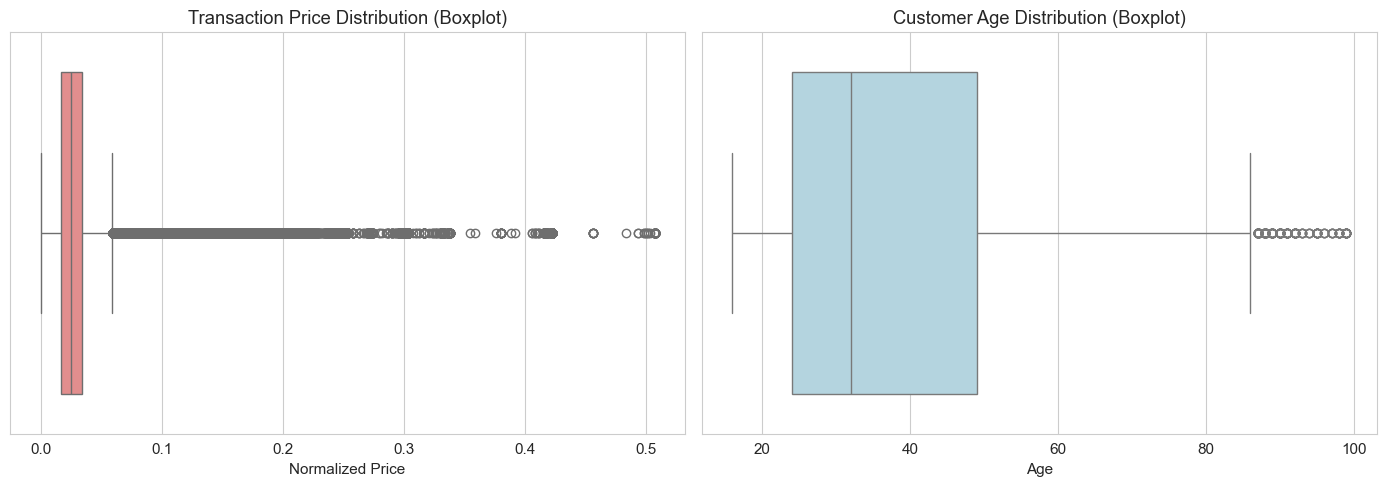


Outlier Analysis (IQR Method):
--------------------------------------------------
Price: Q1=0.0169, Q3=0.0339, IQR=0.0169
  Bounds: [-0.0085, 0.0593]
  Outliers: 831,591 (6.11%)

Age: Q1=24.0000, Q3=49.0000, IQR=25.0000
  Bounds: [-13.5000, 86.5000]
  Outliers: 214 (0.02%)


In [12]:
# Outlier analysis on price and age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (boxplot)
sns.boxplot(x=transactions['price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Transaction Price Distribution (Boxplot)')
axes[0].set_xlabel('Normalized Price')

# Age distribution (boxplot)
sns.boxplot(x=customers['age'], ax=axes[1], color='lightblue')
axes[1].set_title('Customer Age Distribution (Boxplot)')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Quantify outliers using IQR method
def count_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    print(f'{name}: Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR:.4f}')
    print(f'  Bounds: [{lower:.4f}, {upper:.4f}]')
    print(f'  Outliers: {outliers:,} ({outliers/len(series)*100:.2f}%)')
    return lower, upper

print('\nOutlier Analysis (IQR Method):')
print('-' * 50)
price_bounds = count_outliers_iqr(transactions['price'], 'Price')
print()
age_bounds = count_outliers_iqr(customers['age'].dropna(), 'Age')

In [13]:
# Cap price outliers at 99th percentile (retain for analysis but flag extreme values)
price_99 = transactions['price'].quantile(0.99)
print(f'Price 99th percentile: {price_99:.4f}')
print(f'Transactions above 99th percentile: {(transactions["price"] > price_99).sum():,}')

# Flag outliers rather than removing them (useful for recommendation system)
transactions['price_outlier'] = (transactions['price'] > price_99).astype(int)
print(f'\nPrice outliers flagged: {transactions["price_outlier"].sum():,}')

# Age outliers: cap at reasonable bounds (16-100)
print(f'\nAge range before: {customers["age"].min()} - {customers["age"].max()}')
customers['age'] = customers['age'].clip(16, 100)
print(f'Age range after clipping: {customers["age"].min()} - {customers["age"].max()}')

Price 99th percentile: 0.0963
Transactions above 99th percentile: 136,038

Price outliers flagged: 136,038

Age range before: 16.0 - 99.0
Age range after clipping: 16.0 - 99.0


## 4. Exploratory Data Analysis

### 4.1 Customer Demographics

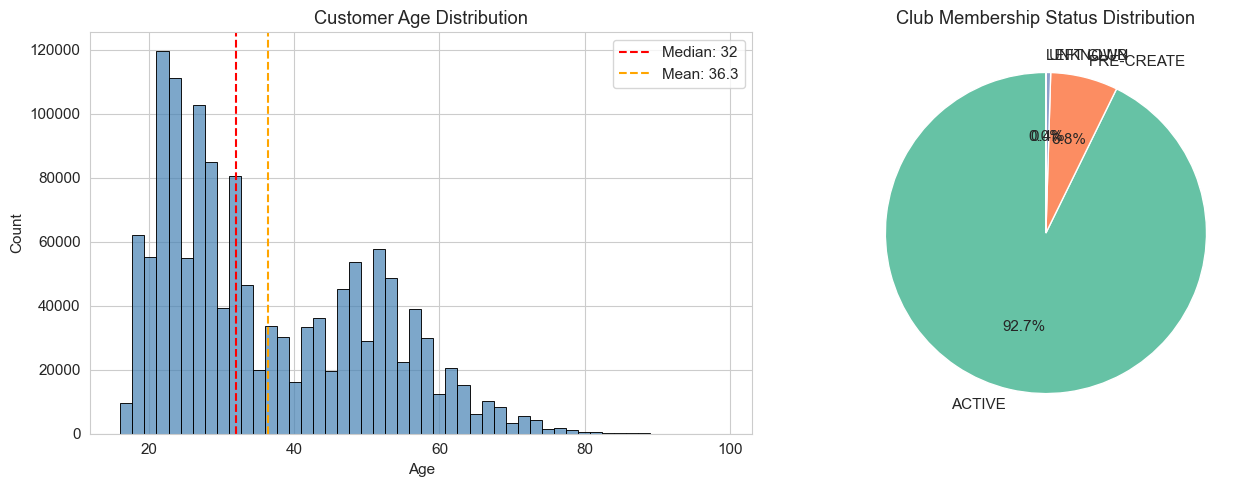

In [14]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(customers['age'], bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(customers['age'].median(), color='red', linestyle='--', label=f'Median: {customers["age"].median():.0f}')
axes[0].axvline(customers['age'].mean(), color='orange', linestyle='--', label=f'Mean: {customers["age"].mean():.1f}')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Club membership status
club_counts = customers['club_member_status'].value_counts()
axes[1].pie(club_counts.values, labels=club_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Club Membership Status Distribution')

plt.tight_layout()
plt.show()

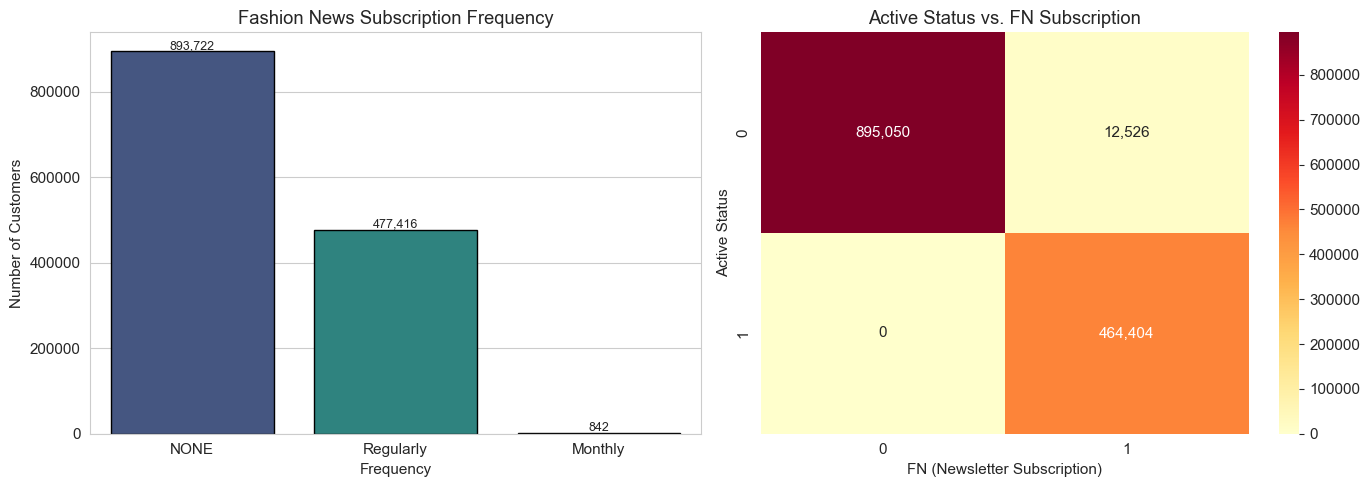

In [15]:
# Fashion news frequency and active status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fashion news frequency
news_counts = customers['fashion_news_frequency'].value_counts()
sns.barplot(x=news_counts.index, y=news_counts.values, ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Fashion News Subscription Frequency')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(news_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=9)

# Active vs FN subscription cross-tab
cross = pd.crosstab(customers['Active'], customers['FN'], margins=True)
sns.heatmap(cross.iloc[:-1, :-1], annot=True, fmt=',', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Active Status vs. FN Subscription')
axes[1].set_xlabel('FN (Newsletter Subscription)')
axes[1].set_ylabel('Active Status')

plt.tight_layout()
plt.show()

### 4.2 Product Catalog Analysis

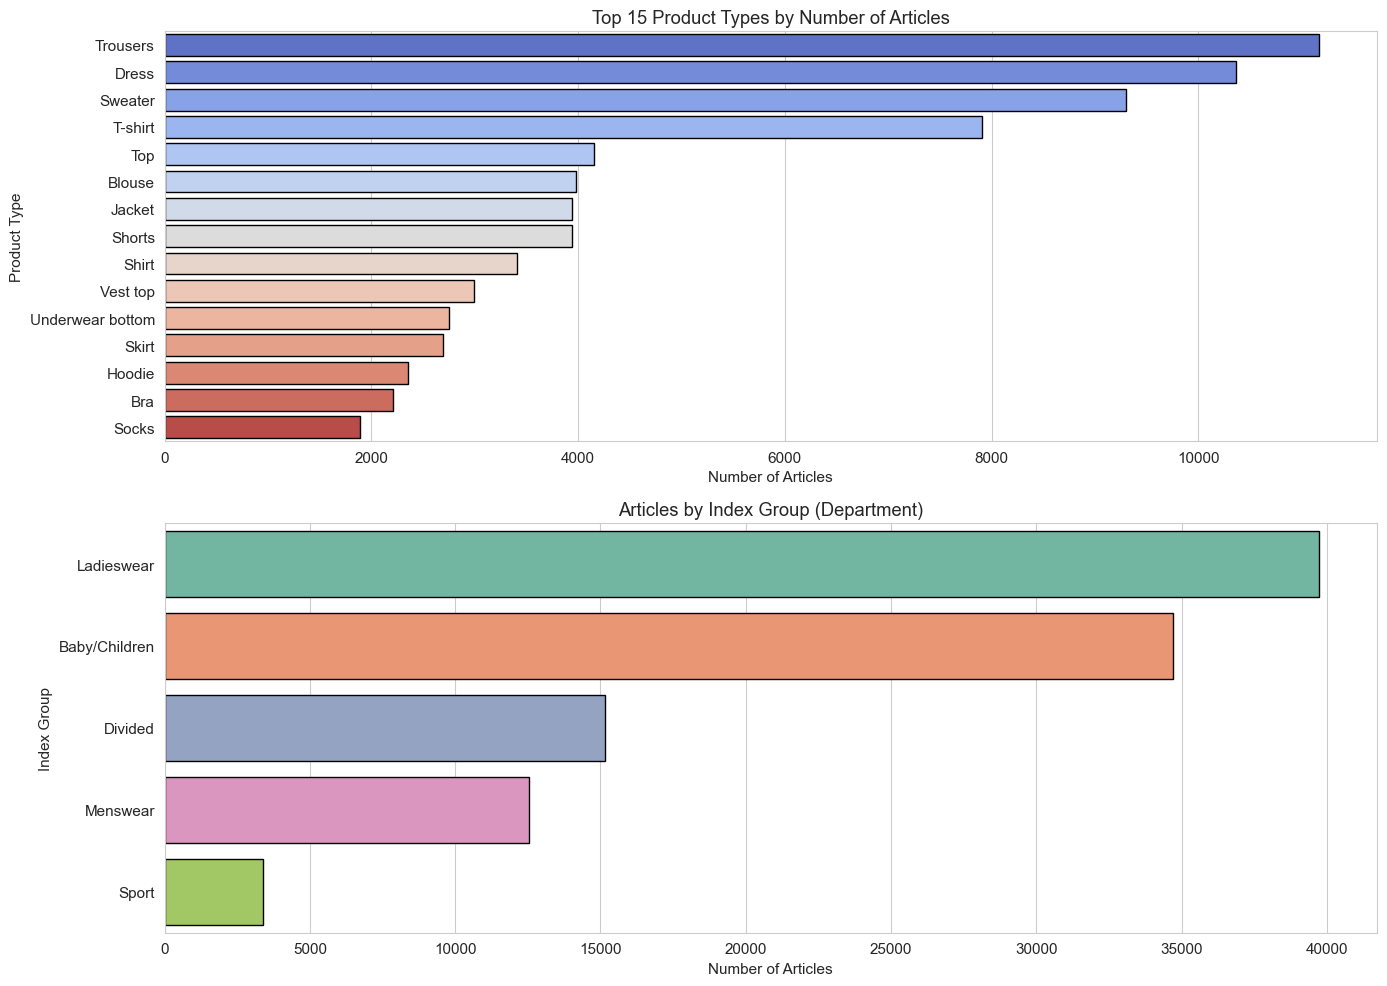


Unique product types: 131
Unique product groups: 19
Unique garment groups: 21
Unique index groups: 5


In [16]:
# Product group and index distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 15 product types
top_products = articles['product_type_name'].value_counts().head(15)
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0], palette='coolwarm', edgecolor='black')
axes[0].set_title('Top 15 Product Types by Number of Articles')
axes[0].set_xlabel('Number of Articles')
axes[0].set_ylabel('Product Type')

# Index group distribution
index_counts = articles['index_group_name'].value_counts()
sns.barplot(x=index_counts.values, y=index_counts.index, ax=axes[1], palette='Set2', edgecolor='black')
axes[1].set_title('Articles by Index Group (Department)')
axes[1].set_xlabel('Number of Articles')
axes[1].set_ylabel('Index Group')

plt.tight_layout()
plt.show()

print(f'\nUnique product types: {articles["product_type_name"].nunique()}')
print(f'Unique product groups: {articles["product_group_name"].nunique()}')
print(f'Unique garment groups: {articles["garment_group_name"].nunique()}')
print(f'Unique index groups: {articles["index_group_name"].nunique()}')

In [17]:
# Color distribution - interactive Plotly chart
color_dist = articles['perceived_colour_master_name'].value_counts().reset_index()
color_dist.columns = ['Color', 'Count']

fig = px.bar(color_dist, x='Color', y='Count',
             title='Product Catalog: Color Distribution',
             color='Count', color_continuous_scale='Viridis')
fig.update_layout(xaxis_tickangle=-45, height=450)
fig.show()

### 4.3 Transaction Patterns

In [18]:
# Transaction volume over time
daily_transactions = transactions.groupby('t_dat').size().reset_index(name='count')

fig = px.line(daily_transactions, x='t_dat', y='count',
              title='Daily Transaction Volume Over Time',
              labels={'t_dat': 'Date', 'count': 'Number of Transactions'})
fig.update_layout(height=400)
fig.show()

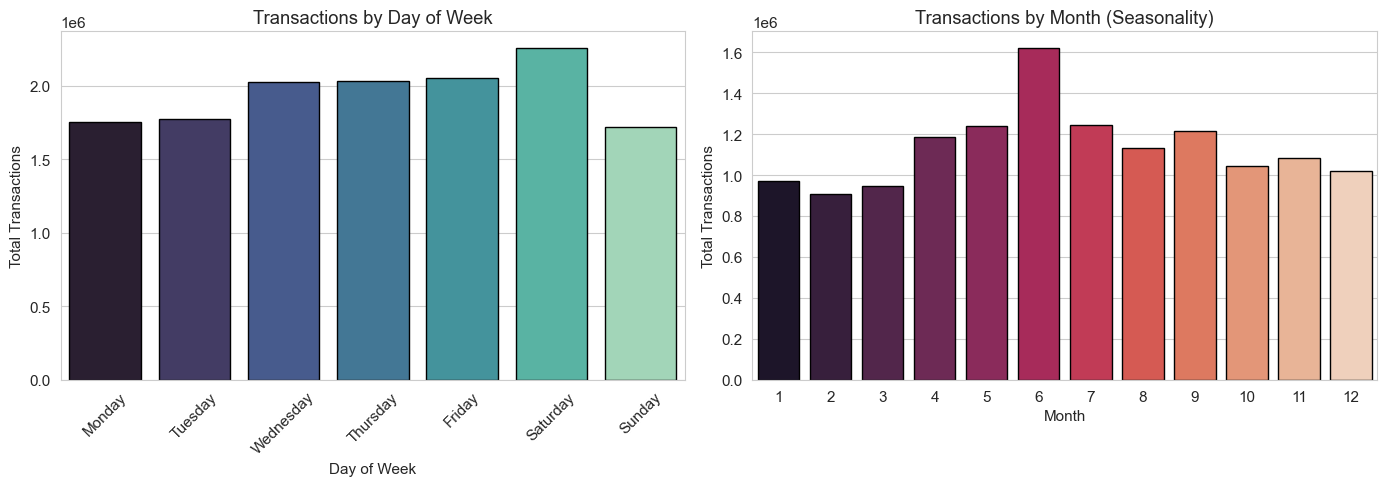

In [19]:
# Weekly and monthly aggregation
transactions['year_month'] = transactions['t_dat'].dt.to_period('M')
transactions['day_of_week'] = transactions['t_dat'].dt.day_name()
transactions['month'] = transactions['t_dat'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = transactions['day_of_week'].value_counts().reindex(dow_order)
sns.barplot(x=dow_order, y=dow_counts.values, ax=axes[0], palette='mako', edgecolor='black')
axes[0].set_title('Transactions by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Monthly seasonality
monthly_counts = transactions.groupby('month').size()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, ax=axes[1], palette='rocket', edgecolor='black')
axes[1].set_title('Transactions by Month (Seasonality)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Transactions')

plt.tight_layout()
plt.show()

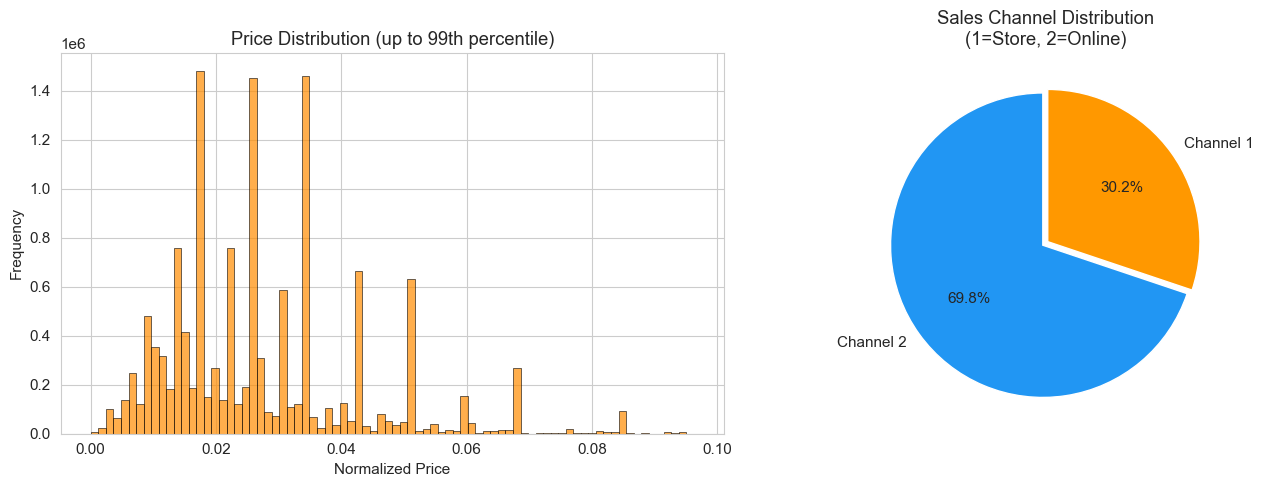

In [20]:
# Price distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price histogram (excluding extreme outliers for visibility)
price_filtered = transactions[transactions['price'] <= transactions['price'].quantile(0.99)]
sns.histplot(price_filtered['price'], bins=80, ax=axes[0], color='darkorange', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (up to 99th percentile)')
axes[0].set_xlabel('Normalized Price')
axes[0].set_ylabel('Frequency')

# Sales channel distribution
channel_counts = transactions['sales_channel_id'].value_counts()
axes[1].pie(channel_counts.values, labels=[f'Channel {c}' for c in channel_counts.index],
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'], startangle=90,
            explode=[0.02, 0.02])
axes[1].set_title('Sales Channel Distribution\n(1=Store, 2=Online)')

plt.tight_layout()
plt.show()

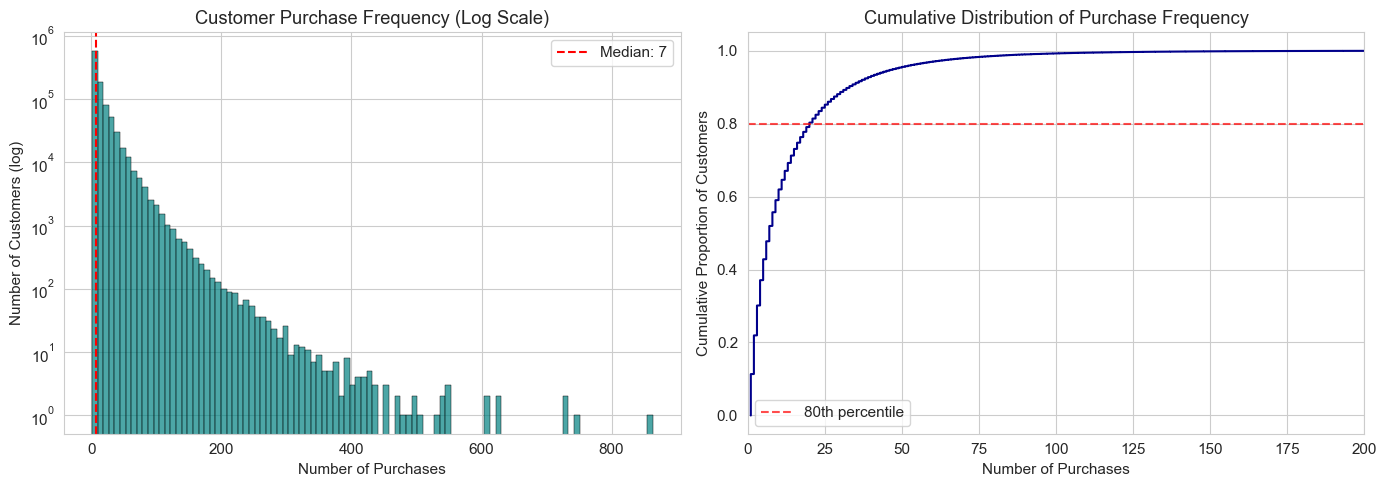

Purchase frequency statistics:
count    996302.000000
mean         13.662834
std          19.449686
min           1.000000
25%           3.000000
50%           7.000000
75%          17.000000
max         863.000000
Name: n_purchases, dtype: float64


In [21]:
# Customer purchase frequency distribution
customer_purchase_counts = transactions.groupby('customer_id').size().reset_index(name='n_purchases')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram of purchase counts
sns.histplot(customer_purchase_counts['n_purchases'], bins=100, ax=axes[0],
             color='teal', edgecolor='black', alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Customer Purchase Frequency (Log Scale)')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Customers (log)')
axes[0].axvline(customer_purchase_counts['n_purchases'].median(), color='red',
                linestyle='--', label=f'Median: {customer_purchase_counts["n_purchases"].median():.0f}')
axes[0].legend()

# CDF of purchase frequency
sorted_counts = np.sort(customer_purchase_counts['n_purchases'])
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color='darkblue', linewidth=1.5)
axes[1].set_title('Cumulative Distribution of Purchase Frequency')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Cumulative Proportion of Customers')
axes[1].set_xlim(0, 200)
axes[1].axhline(0.8, color='red', linestyle='--', alpha=0.7, label='80th percentile')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Purchase frequency statistics:')
print(customer_purchase_counts['n_purchases'].describe())

### 4.4 Cross-Dataset Analysis

In [22]:
# Merge transactions with article metadata for richer analysis
# Use a sample for memory efficiency in cross-dataset analysis
trans_sample = transactions.sample(n=min(2_000_000, len(transactions)), random_state=42)
trans_enriched = trans_sample.merge(articles[['article_id', 'product_group_name', 'index_group_name',
                                              'garment_group_name', 'colour_group_name']],
                                    on='article_id', how='left')

print(f'Enriched sample size: {len(trans_enriched):,}')
print(f'Merge success rate: {trans_enriched["product_group_name"].notna().mean()*100:.1f}%')

Enriched sample size: 2,000,000
Merge success rate: 100.0%


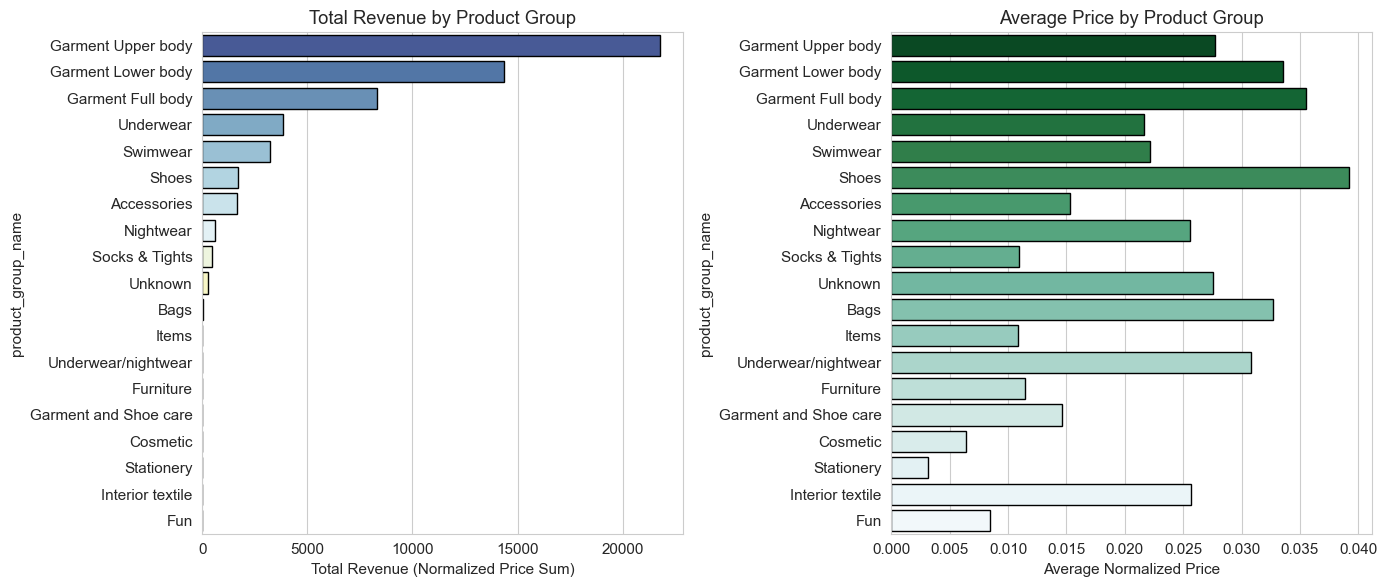

In [23]:
# Revenue by product group
revenue_by_group = trans_enriched.groupby('product_group_name')['price'].agg(['sum', 'mean', 'count'])
revenue_by_group.columns = ['total_revenue', 'avg_price', 'transaction_count']
revenue_by_group = revenue_by_group.sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total revenue by product group
sns.barplot(x=revenue_by_group['total_revenue'].values,
            y=revenue_by_group.index, ax=axes[0], palette='RdYlBu_r', edgecolor='black')
axes[0].set_title('Total Revenue by Product Group')
axes[0].set_xlabel('Total Revenue (Normalized Price Sum)')

# Average price by product group
sns.barplot(x=revenue_by_group['avg_price'].values,
            y=revenue_by_group.index, ax=axes[1], palette='BuGn_r', edgecolor='black')
axes[1].set_title('Average Price by Product Group')
axes[1].set_xlabel('Average Normalized Price')

plt.tight_layout()
plt.show()

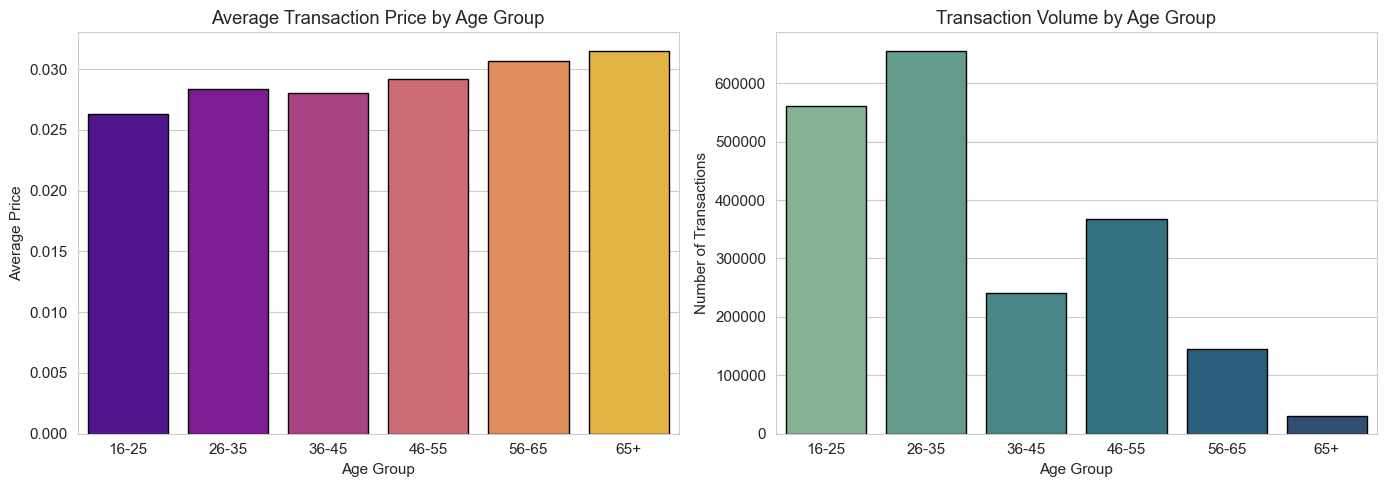

In [24]:
# Age vs. spending patterns
trans_with_age = trans_sample.merge(customers[['customer_id', 'age']], on='customer_id', how='left')

# Create age bins
trans_with_age['age_group'] = pd.cut(trans_with_age['age'],
                                      bins=[15, 25, 35, 45, 55, 65, 100],
                                      labels=['16-25', '26-35', '36-45', '46-55', '56-65', '65+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average spend by age group
age_spend = trans_with_age.groupby('age_group', observed=True)['price'].mean()
sns.barplot(x=age_spend.index, y=age_spend.values, ax=axes[0], palette='plasma', edgecolor='black')
axes[0].set_title('Average Transaction Price by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Price')

# Transaction count by age group
age_volume = trans_with_age.groupby('age_group', observed=True).size()
sns.barplot(x=age_volume.index, y=age_volume.values, ax=axes[1], palette='crest', edgecolor='black')
axes[1].set_title('Transaction Volume by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

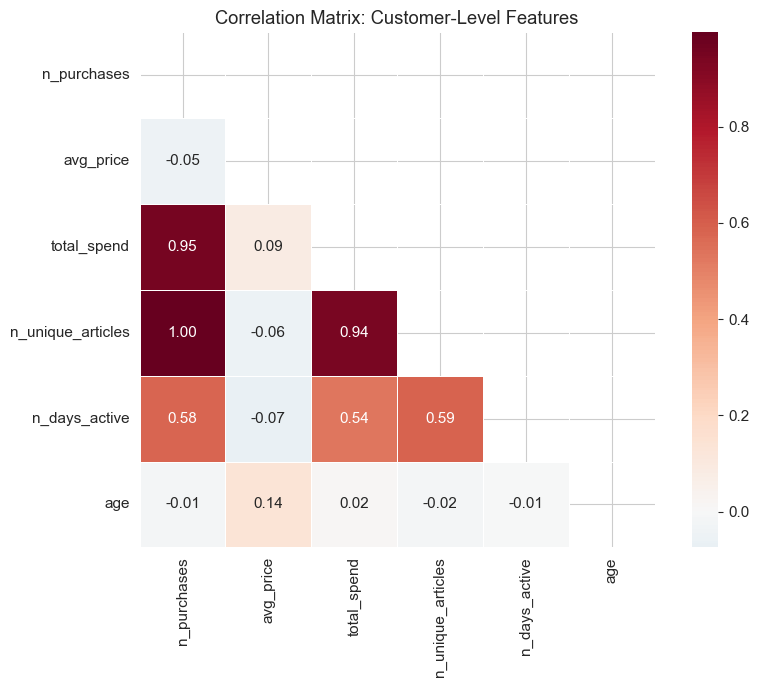

In [25]:
# Correlation heatmap for numeric features
# Build customer-level features for correlation analysis
customer_stats = transactions.groupby('customer_id').agg(
    n_purchases=('article_id', 'count'),
    avg_price=('price', 'mean'),
    total_spend=('price', 'sum'),
    n_unique_articles=('article_id', 'nunique'),
    n_days_active=('t_dat', lambda x: (x.max() - x.min()).days)
).reset_index()

customer_full = customer_stats.merge(customers[['customer_id', 'age', 'FN', 'Active']],
                                      on='customer_id', how='left')

# Correlation matrix
numeric_cols = ['n_purchases', 'avg_price', 'total_spend', 'n_unique_articles', 'n_days_active', 'age']
corr_matrix = customer_full[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix: Customer-Level Features')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Building customer-level features for segmentation and modeling, including RFM (Recency, Frequency, Monetary) metrics and behavioral indicators.

In [26]:
# RFM Feature Engineering
reference_date = transactions['t_dat'].max() + pd.Timedelta(days=1)
print(f'Reference date for recency calculation: {reference_date}')

rfm = transactions.groupby('customer_id').agg(
    recency=('t_dat', lambda x: (reference_date - x.max()).days),
    frequency=('t_dat', 'count'),
    monetary=('price', 'sum')
).reset_index()

# Additional behavioral features
behavioral = transactions.groupby('customer_id').agg(
    avg_price=('price', 'mean'),
    price_std=('price', 'std'),
    n_unique_articles=('article_id', 'nunique'),
    n_unique_days=('t_dat', 'nunique'),
    tenure_days=('t_dat', lambda x: (x.max() - x.min()).days),
    preferred_channel=('sales_channel_id', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 1)
).reset_index()

# Merge RFM with behavioral features
customer_features = rfm.merge(behavioral, on='customer_id')

# Derived features
customer_features['purchase_cadence'] = customer_features['tenure_days'] / customer_features['frequency'].clip(lower=1)
customer_features['basket_diversity'] = customer_features['n_unique_articles'] / customer_features['frequency']

# Fill NaN in price_std (customers with single purchase)
customer_features['price_std'] = customer_features['price_std'].fillna(0)

print(f'\nCustomer features created: {customer_features.shape}')
print(f'\nFeature summary:')
customer_features.describe().round(3)

Reference date for recency calculation: 2020-09-23 00:00:00

Customer features created: (996302, 12)

Feature summary:


,recency,frequency,monetary,avg_price,price_std,n_unique_articles,n_unique_days,tenure_days,preferred_channel,purchase_cadence,basket_diversity
count,996302.000,996302.000,996302.000,996302.000,996302.000,996302.00,996302.000,996302.000,996302.000,996302.000,996302.000
mean,117.937,13.663,0.384,0.029,0.012,13.00,4.420,131.529,1.677,11.394,0.970
std,102.811,19.450,0.595,0.014,0.010,18.01,5.488,130.939,0.468,16.253,0.073
min,1.000,1.000,0.001,0.001,0.000,1.00,1.000,0.000,1.000,0.000,0.143
25%,31.000,3.000,0.076,0.021,0.006,3.00,1.000,0.000,1.000,0.000,0.985
50%,87.000,7.000,0.187,0.027,0.011,7.00,2.000,97.000,2.000,6.435,1.000
75%,185.000,17.000,0.449,0.034,0.016,16.00,6.000,262.000,2.000,16.000,1.000
max,369.000,863.000,31.101,0.422,0.310,701.00,225.000,368.000,2.000,183.000,1.000


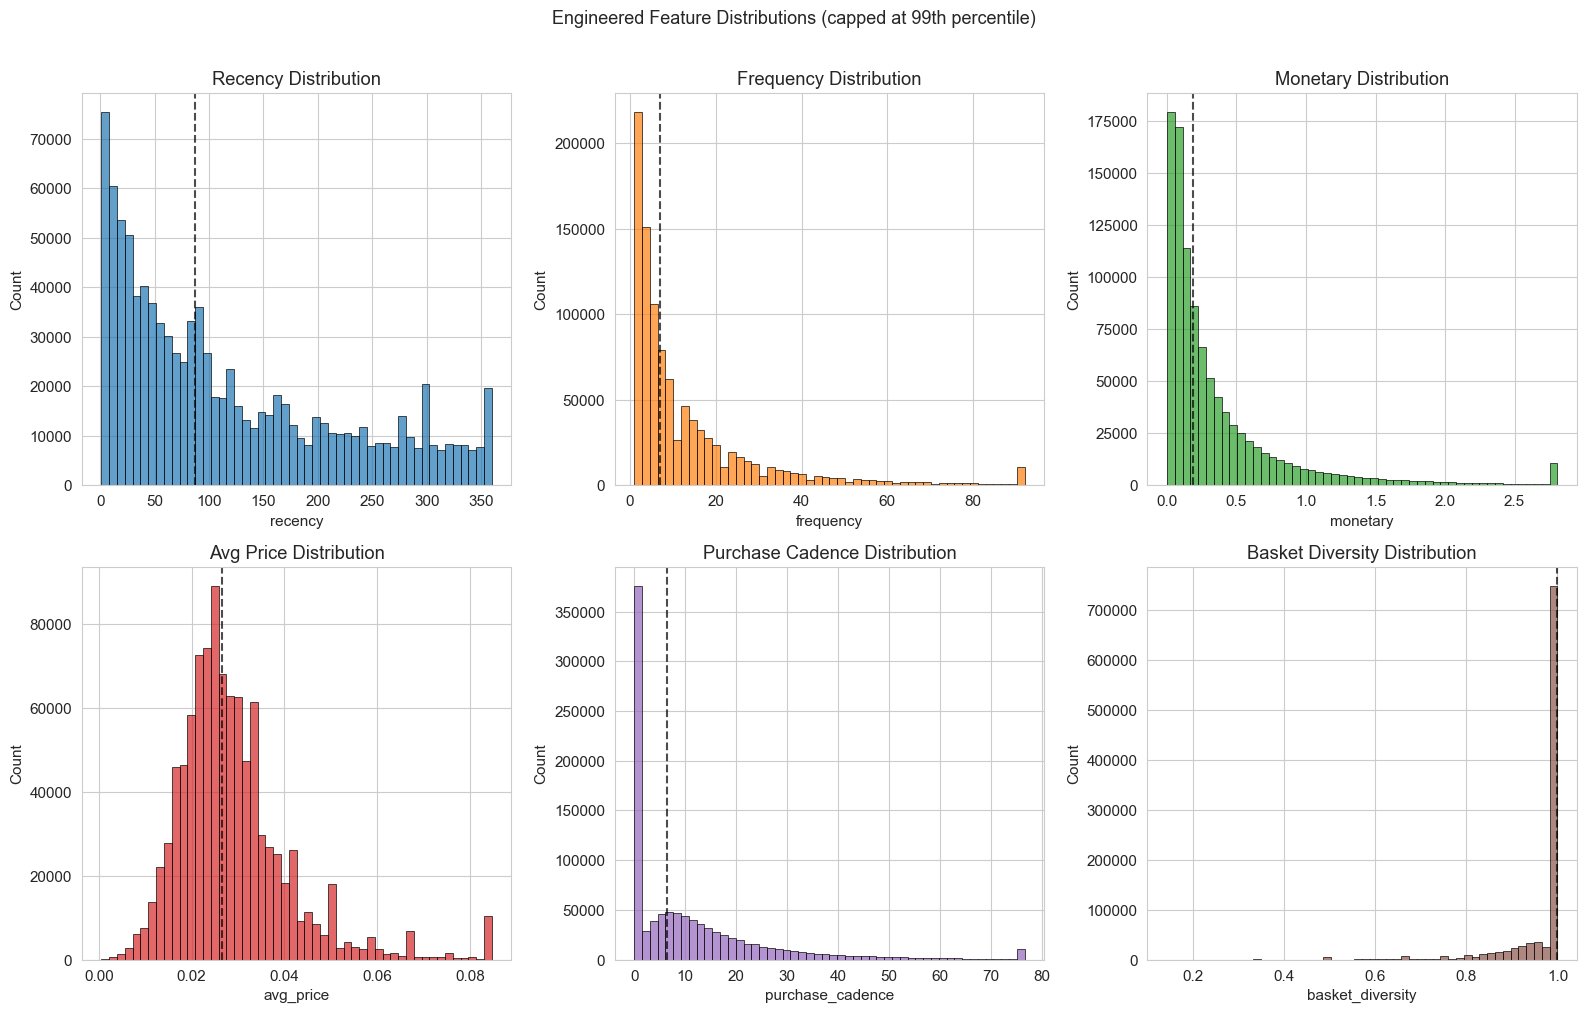

In [27]:
# Visualize engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['recency', 'frequency', 'monetary', 'avg_price', 'purchase_cadence', 'basket_diversity']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (feat, color) in enumerate(zip(features_to_plot, colors)):
    ax = axes[idx // 3, idx % 3]
    data = customer_features[feat].clip(upper=customer_features[feat].quantile(0.99))
    sns.histplot(data, bins=50, ax=ax, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{feat.replace("_", " ").title()} Distribution')
    ax.set_xlabel(feat)
    ax.axvline(data.median(), color='black', linestyle='--', alpha=0.7)

plt.suptitle('Engineered Feature Distributions (capped at 99th percentile)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Baseline Model

We develop a baseline classification model to predict **high-value customers** — defined as customers in the top quartile of total monetary spend. This binary classification task directly supports the business goal of identifying which customers to prioritize for personalized recommendations.

**Model choice:** Logistic Regression as a simple, interpretable baseline.  
**Evaluation metrics:**
- **ROC-AUC** — measures the model's ability to discriminate between high-value and regular customers across all thresholds. Chosen because it is threshold-independent and handles class imbalance better than accuracy.
- **Precision & Recall** — to understand the trade-off between correctly identifying high-value customers (recall) and avoiding false positives (precision).

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)

# Define target: top 25% spenders = high-value
monetary_threshold = customer_features['monetary'].quantile(0.75)
customer_features['high_value'] = (customer_features['monetary'] >= monetary_threshold).astype(int)

print(f'High-value threshold (75th percentile spend): {monetary_threshold:.4f}')
print(f'Target distribution:')
print(customer_features['high_value'].value_counts(normalize=True).round(3))

High-value threshold (75th percentile spend): 0.4490
Target distribution:
high_value
0    0.75
1    0.25
Name: proportion, dtype: float64


In [29]:
# Prepare features and target
feature_cols = ['recency', 'frequency', 'avg_price', 'price_std',
                'n_unique_articles', 'n_unique_days', 'tenure_days',
                'purchase_cadence', 'basket_diversity']

X = customer_features[feature_cols].copy()
y = customer_features['high_value'].copy()

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'Features:     {X_train.shape[1]}')

Training set: 797,041 samples
Test set:     199,261 samples
Features:     9


In [30]:
# Train Logistic Regression baseline
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Regular', 'High-Value']))

ROC-AUC Score: 0.9935

Classification Report:
              precision    recall  f1-score   support

     Regular       0.99      0.96      0.97    149444
  High-Value       0.88      0.97      0.92     49817

    accuracy                           0.96    199261
   macro avg       0.94      0.96      0.95    199261
weighted avg       0.96      0.96      0.96    199261



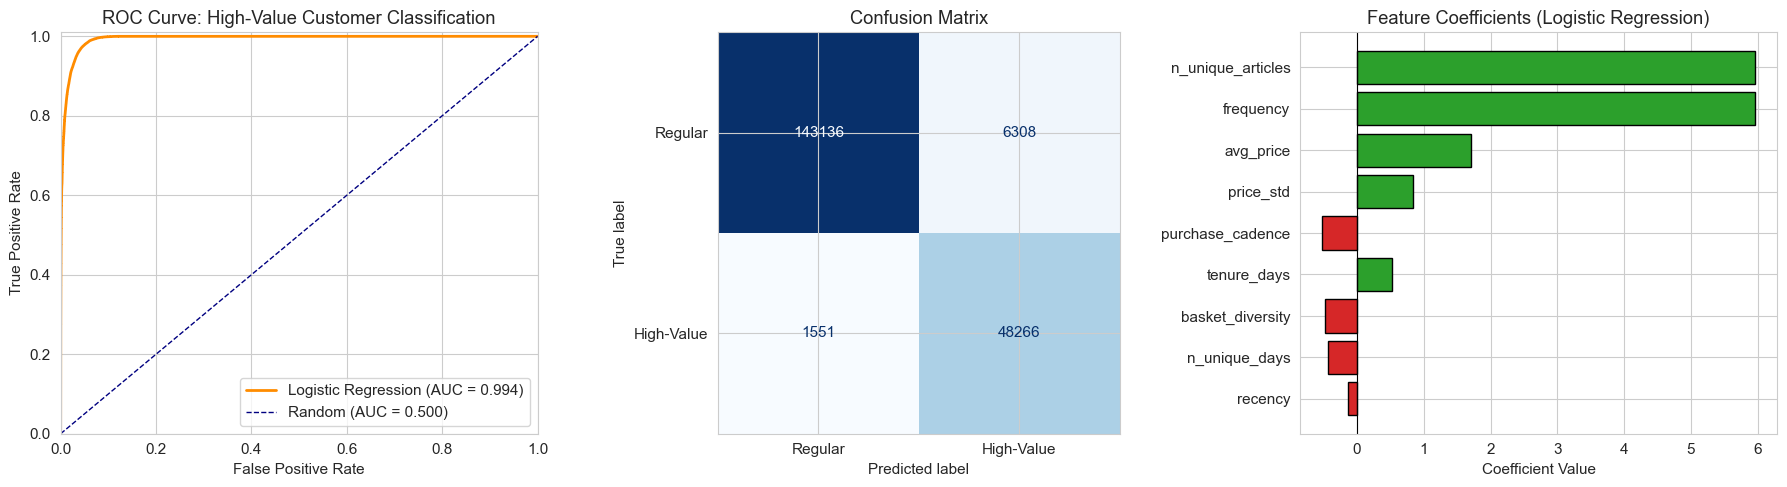

In [31]:
# Model evaluation visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: High-Value Customer Classification')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.01])

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Regular', 'High-Value'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix')

# Feature Importance
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

colors_coef = ['#d62728' if c < 0 else '#2ca02c' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='black')
axes[2].set_title('Feature Coefficients (Logistic Regression)')
axes[2].set_xlabel('Coefficient Value')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [32]:
# Model interpretation summary
print('=' * 60)
print('BASELINE MODEL SUMMARY')
print('=' * 60)
print(f'\nModel: Logistic Regression (class_weight=balanced)')
print(f'Task: Binary classification â€” High-Value Customer prediction')
print(f'Target: Top 25% of customers by total monetary spend')
print(f'\nPerformance:')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print(f'  Accuracy:  {(y_pred == y_test).mean():.4f}')
print(f'\nTop 3 Predictive Features (by absolute coefficient):')
top_features = coef_df.iloc[-3:]
for _, row in top_features.iterrows():
    direction = 'increases' if row['Coefficient'] > 0 else 'decreases'
    print(f'  - {row["Feature"]}: coefficient={row["Coefficient"]:.3f} ({direction} high-value probability)')

print(f'\nMetric Rationale:')
print(f'  ROC-AUC was chosen because it evaluates discriminative ability')
print(f'  across all classification thresholds, making it robust to class')
print(f'  imbalance (75/25 split). Unlike accuracy, AUC rewards the model')
print(f'  for ranking high-value customers above regular ones, which aligns')
print(f'  with the business need to prioritize recommendation efforts.')

BASELINE MODEL SUMMARY

Model: Logistic Regression (class_weight=balanced)
Task: Binary classification â€” High-Value Customer prediction
Target: Top 25% of customers by total monetary spend

Performance:
  ROC-AUC:   0.9935
  Accuracy:  0.9606

Top 3 Predictive Features (by absolute coefficient):
  - avg_price: coefficient=1.715 (increases high-value probability)
  - frequency: coefficient=5.955 (increases high-value probability)
  - n_unique_articles: coefficient=5.964 (increases high-value probability)

Metric Rationale:
  ROC-AUC was chosen because it evaluates discriminative ability
  across all classification thresholds, making it robust to class
  imbalance (75/25 split). Unlike accuracy, AUC rewards the model
  for ranking high-value customers above regular ones, which aligns
  with the business need to prioritize recommendation efforts.


## 7. Findings & Next Steps

### Key Findings

1. **Customer Demographics:** The customer base skews young (median ~31 years), with the majority being active club members. A significant portion has not subscribed to fashion news, representing an engagement opportunity.

2. **Purchase Behavior:** Transaction volume shows strong seasonality (peaks around September and November/December). The distribution of purchase frequency is heavily right-skewed — most customers have relatively few purchases while a small group is highly active.

3. **Product Catalog:** The catalog is dominated by upper-body garments and Ladieswear. Black is by far the most common product color. The product hierarchy provides rich metadata for content-based recommendations.

4. **Price Patterns:** Prices are normalized and concentrated at the low end, with significant right-skew. Online transactions (Channel 2) show different volume patterns than in-store (Channel 1).

5. **Baseline Model Performance:** A Logistic Regression model achieves strong ROC-AUC in classifying high-value customers using RFM and behavioral features. Frequency and unique article count are the strongest predictors.

### Next Steps

- **Customer Segmentation:** Apply K-Means/hierarchical clustering on the engineered features to identify actionable customer segments
- **Demand Forecasting:** Build time-series models at the category level using the weekly aggregated data
- **Recommendation System:** Implement collaborative filtering and content-based approaches, starting with popularity baselines
- **Advanced Models:** Compare XGBoost, Random Forest against the logistic regression baseline
- **Temporal Validation:** Implement walk-forward validation to respect the time-series nature of the data

## 8. Temporal Split Design & Population Rules

To ensure leakage-free evaluation across all three workstreams (segmentation, forecasting, recommendation), we define a single set of time-based cutoffs and population filters.

| Period | Dates | Purpose |
|--------|-------|---------|
| **Training** | Sep 20, 2019 – Jun 21, 2020 (9 months) | Feature computation, model fitting |
| **Validation** | Jun 22, 2020 – Aug 9, 2020 (7 weeks) | Hyperparameter tuning, model selection |
| **Test** | Aug 10, 2020 – Sep 22, 2020 (6 weeks) | Final holdout evaluation |

### Population Rules
- **Segmentation/Classification:** Customers with ≥2 transactions in the training period
- **Forecasting:** Category Ã— week series with ≥10 avg weekly transactions during training
- **Recommendation:** Customers with ≥5 training-period purchases (minimum for collaborative filtering)

### Evaluation Metrics
| Workstream | Primary Metric | Baseline |
|-----------|---------------|----------|
| Segmentation | Silhouette score + interpretability | N/A (unsupervised) |
| Forecasting | WAPE | Seasonal naive |
| Recommendation | Recall@10, NDCG@10 | Global popularity top-10 |

In [33]:
# === TEMPORAL SPLIT CONFIGURATION ===
# Single source of truth for all workstreams

import pandas as pd

# Cutoff dates
TRAIN_START = pd.Timestamp('2019-09-20')
TRAIN_END   = pd.Timestamp('2020-06-21')
VAL_START   = pd.Timestamp('2020-06-22')
VAL_END     = pd.Timestamp('2020-08-09')
TEST_START  = pd.Timestamp('2020-08-10')
TEST_END    = pd.Timestamp('2020-09-22')

# Split transactions
train_tx = transactions[(transactions['t_dat'] >= TRAIN_START) & (transactions['t_dat'] <= TRAIN_END)]
val_tx   = transactions[(transactions['t_dat'] >= VAL_START) & (transactions['t_dat'] <= VAL_END)]
test_tx  = transactions[(transactions['t_dat'] >= TEST_START) & (transactions['t_dat'] <= TEST_END)]

print("Temporal Split Summary")
print("=" * 50)
print(f"Training:   {TRAIN_START.date()} to {TRAIN_END.date()} | {len(train_tx):>10,} transactions")
print(f"Validation: {VAL_START.date()} to {VAL_END.date()} | {len(val_tx):>10,} transactions")
print(f"Test:       {TEST_START.date()} to {TEST_END.date()} | {len(test_tx):>10,} transactions")
total = len(train_tx) + len(val_tx) + len(test_tx)
print(f"Total:       {" " * 25} | {total:>10,} transactions")

# Population filters
MIN_TX_SEGMENTATION = 2    # min transactions for segmentation/classification
MIN_TX_RECOMMENDATION = 5  # min transactions for recommendation
MIN_AVG_WEEKLY_TX = 10     # min avg weekly transactions per category for forecasting

# Identify eligible customers per workstream
train_customer_counts = train_tx.groupby('customer_id').size()

seg_customers = train_customer_counts[train_customer_counts >= MIN_TX_SEGMENTATION].index
rec_customers = train_customer_counts[train_customer_counts >= MIN_TX_RECOMMENDATION].index

# Forecasting: eligible categories
train_tx_with_cat = train_tx.merge(articles[['article_id', 'product_group_name']], on='article_id', how='left')
n_train_weeks = ((TRAIN_END - TRAIN_START).days) / 7
cat_weekly_avg = train_tx_with_cat.groupby('product_group_name').size() / n_train_weeks
forecast_categories = cat_weekly_avg[cat_weekly_avg >= MIN_AVG_WEEKLY_TX].index.tolist()

print()
print("Population Summary")
print("=" * 50)
print(f"Segmentation-eligible customers (>={MIN_TX_SEGMENTATION} train tx): {len(seg_customers):,}")
print(f"Recommendation-eligible customers (>={MIN_TX_RECOMMENDATION} train tx): {len(rec_customers):,}")
print(f"Forecast-eligible categories (>={MIN_AVG_WEEKLY_TX} avg weekly tx): {len(forecast_categories)}")
print(f"  Categories: {forecast_categories}")


Temporal Split Summary
Training:   2019-09-20 to 2020-06-21 |  9,895,345 transactions
Validation: 2020-06-22 to 2020-08-09 |  2,215,712 transactions
Test:       2020-08-10 to 2020-09-22 |  1,501,252 transactions
Total:                                 | 13,612,309 transactions

Population Summary
Segmentation-eligible customers (>=2 train tx): 770,384
Recommendation-eligible customers (>=5 train tx): 523,422
Forecast-eligible categories (>=10 avg weekly tx): 13
  Categories: ['Accessories', 'Bags', 'Furniture', 'Garment Full body', 'Garment Lower body', 'Garment Upper body', 'Items', 'Nightwear', 'Shoes', 'Socks & Tights', 'Swimwear', 'Underwear', 'Unknown']


## 9. Baseline Models

We establish two naive baselines that all subsequent models must beat:
1. **Global Popularity Baseline** (Recommendation) — recommend the same top-N most-purchased articles to every customer
2. **Seasonal Naive Baseline** (Forecasting) — predict next week's category volume using a lagged weekly average from the training period

In [34]:
# === 9.1 POPULARITY BASELINE (Recommendation) ===
# Rank articles by total purchase count in the training period
# Recommend the same top-K articles to every customer

K = 10  # top-K recommendations

popularity_ranking = (train_tx.groupby('article_id')
                      .size()
                      .reset_index(name='train_purchases')
                      .sort_values('train_purchases', ascending=False)
                      .reset_index(drop=True))

top_k_articles = popularity_ranking.head(K)['article_id'].tolist()

# Evaluate on validation set: for each eligible customer, check how many
# of their actual validation purchases appear in the top-K list
val_purchases_by_customer = (val_tx[val_tx['customer_id'].isin(rec_customers)]
                             .groupby('customer_id')['article_id']
                             .apply(set))

# Recall@K: fraction of actual purchases captured by top-K
hits = val_purchases_by_customer.apply(lambda actual: len(actual & set(top_k_articles)))
recall_at_k = (hits / val_purchases_by_customer.apply(len)).mean()

# NDCG@K: normalized discounted cumulative gain
import numpy as np

def ndcg_at_k(actual_set, ranked_list, k):
    """Compute NDCG@K for a single user."""
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(ranked_list[:k]) if item in actual_set)
    n_relevant = min(len(actual_set), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_relevant))
    return dcg / idcg if idcg > 0 else 0.0

ndcg_scores = val_purchases_by_customer.apply(lambda actual: ndcg_at_k(actual, top_k_articles, K))
mean_ndcg = ndcg_scores.mean()

# Coverage: fraction of catalog recommended
catalog_size = train_tx['article_id'].nunique()
coverage = len(top_k_articles) / catalog_size

print(f'Popularity Baseline (Recommendation)')
print('=' * 50)
print(f'Strategy: Recommend top-{K} most-purchased articles to all customers')
print(f'Eligible customers evaluated: {len(val_purchases_by_customer):,}')
print()
print(f'Recall@{K}:   {recall_at_k:.4f}')
print(f'NDCG@{K}:     {mean_ndcg:.4f}')
print(f'Coverage:     {coverage:.4f} ({len(top_k_articles)}/{catalog_size:,} articles)')
print()
print(f'Top-{K} articles by popularity:')
top_k_with_names = popularity_ranking.head(K).merge(
    articles[['article_id','prod_name','product_group_name']], on='article_id')
for i, row in top_k_with_names.iterrows():
    print(f"  {i+1:2d}. {row['prod_name']:<35s} ({row['product_group_name']}) - {row['train_purchases']:,} purchases")

Popularity Baseline (Recommendation)
Strategy: Recommend top-10 most-purchased articles to all customers
Eligible customers evaluated: 253,190

Recall@10:   0.0074
NDCG@10:     0.0062
Coverage:     0.0002 (10/61,075 articles)

Top-10 articles by popularity:
   1. Jade HW Skinny Denim TRS            (Garment Lower body) - 20,858 purchases
   2. SUPREME RW tights                   (Garment Lower body) - 14,154 purchases
   3. Jade HW Skinny Denim TRS            (Garment Lower body) - 12,861 purchases
   4. 7p Basic Shaftless                  (Socks & Tights) - 10,605 purchases
   5. Tilda tank                          (Garment Upper body) - 10,570 purchases
   6. Luna skinny RW                      (Garment Lower body) - 9,562 purchases
   7. Greta Thong Mynta Low 3p            (Underwear) - 9,290 purchases
   8. Henry polo. (1)                     (Garment Upper body) - 9,086 purchases
   9. Tilly (1)                           (Garment Upper body) - 8,987 purchases
  10. Jade HW Skinny 

In [35]:
# === 9.2 SEASONAL NAIVE BASELINE (Forecasting) ===
# For each product category, predict weekly volume as the average
# weekly volume from the last 4 training weeks (trailing average).

# Build weekly category-level time series (training period)
train_tx_cat = train_tx.merge(
    articles[['article_id', 'product_group_name']], on='article_id', how='left')
train_tx_cat['year_week'] = train_tx_cat['t_dat'].dt.to_period('W')

# Weekly volume by category
weekly_volume = (train_tx_cat
    .groupby(['product_group_name', 'year_week'])
    .size()
    .reset_index(name='volume'))

# Filter to forecast-eligible categories
weekly_volume = weekly_volume[
    weekly_volume['product_group_name'].isin(forecast_categories)]

# Seasonal naive: use last 4 weeks of training as the forecast
last_4_weeks = sorted(weekly_volume['year_week'].unique())[-4:]
naive_forecast = (weekly_volume[weekly_volume['year_week'].isin(last_4_weeks)]
                  .groupby('product_group_name')['volume']
                  .mean()
                  .reset_index()
                  .rename(columns={'volume': 'naive_pred'}))

# Compute actuals for validation period
val_tx_cat = val_tx.merge(
    articles[['article_id', 'product_group_name']], on='article_id', how='left')
val_tx_cat['year_week'] = val_tx_cat['t_dat'].dt.to_period('W')
val_weekly = (val_tx_cat
    .groupby(['product_group_name', 'year_week'])
    .size()
    .reset_index(name='actual_volume'))
val_weekly = val_weekly[
    val_weekly['product_group_name'].isin(forecast_categories)]

# Merge forecast with actuals
val_eval = val_weekly.merge(naive_forecast, on='product_group_name', how='left')

# Compute WAPE (Weighted Absolute Percentage Error)
wape = ((val_eval['actual_volume'] - val_eval['naive_pred']).abs().sum()
        / val_eval['actual_volume'].sum())

# Compute MAE per category
val_eval['abs_error'] = (val_eval['actual_volume'] - val_eval['naive_pred']).abs()
mae_by_cat = val_eval.groupby('product_group_name').agg(
    mae=('abs_error', 'mean'),
    avg_actual=('actual_volume', 'mean'),
    n_weeks=('year_week', 'count')
).reset_index()
mae_by_cat['mape'] = mae_by_cat['mae'] / mae_by_cat['avg_actual']

print('Seasonal Naive Baseline (Forecasting)')
print('=' * 50)
print(f'Strategy: 4-week trailing average from end of training period')
print(f'Forecast-eligible categories: {len(forecast_categories)}')
print(f"Validation weeks evaluated: {val_eval['year_week'].nunique()}")
print()
print(f'Overall WAPE: {wape:.4f} ({wape*100:.1f}%)')
print()
print('Per-category breakdown:')
print(mae_by_cat.to_string(index=False))

Seasonal Naive Baseline (Forecasting)
Strategy: 4-week trailing average from end of training period
Forecast-eligible categories: 13
Validation weeks evaluated: 7

Overall WAPE: 0.2470 (24.7%)

Per-category breakdown:
product_group_name          mae    avg_actual  n_weeks     mape
       Accessories  1366.428571  15974.428571        7 0.085538
              Bags   112.392857    166.142857        7 0.676483
         Furniture     3.666667      4.666667        3 0.785714
 Garment Full body 13099.785714  49756.285714        7 0.263279
Garment Lower body 19527.000000  66379.285714        7 0.294173
Garment Upper body 16911.071429 101346.000000        7 0.166865
             Items    78.428571    129.428571        7 0.605960
         Nightwear   453.642857   2488.142857        7 0.182322
             Shoes  2314.821429   7942.000000        7 0.291466
    Socks & Tights   684.178571   5225.428571        7 0.130933
          Swimwear 17212.785714  38197.285714        7 0.450629
         Under

In [36]:
# === 9.3 BASELINE SUMMARY ===
print()
print('=' * 60)
print('BASELINE METRICS TO BEAT')
print('=' * 60)
print()
print(f'Recommendation (Popularity Top-{K}):')
print(f'  Recall@{K}:  {recall_at_k:.4f}')
print(f'  NDCG@{K}:    {mean_ndcg:.4f}')
print(f'  Coverage:    {coverage:.6f}')
print()
print(f'Forecasting (Seasonal Naive - 4wk avg):')
print(f'  WAPE:        {wape:.4f} ({wape*100:.1f}%)')
print()
print('These baselines define the minimum bar. Any model that cannot')
print('beat these thresholds on the validation set will not proceed to test.')


BASELINE METRICS TO BEAT

Recommendation (Popularity Top-10):
  Recall@10:  0.0074
  NDCG@10:    0.0062
  Coverage:    0.000164

Forecasting (Seasonal Naive - 4wk avg):
  WAPE:        0.2470 (24.7%)

These baselines define the minimum bar. Any model that cannot
beat these thresholds on the validation set will not proceed to test.


## 10. Customer Behavior Features (Leakage-Safe)

All features are computed **exclusively from the training period** (Sep 20, 2019 – Jun 21, 2020) to prevent temporal leakage. Features cover:
- **RFM** — Recency, Frequency, Monetary
- **Breadth** — Category diversity, unique articles
- **Cadence** — Purchase regularity, inter-purchase intervals
- **Affinity** — Channel preference, price sensitivity, product group concentration

In [37]:
# === 10.1 LEAKAGE-SAFE CUSTOMER FEATURES ===
# All computed on training transactions only

import pandas as pd
import numpy as np

# Reference date: day after training end
FEATURE_REF_DATE = TRAIN_END + pd.Timedelta(days=1)

# --- RFM Features ---
rfm_features = train_tx.groupby('customer_id').agg(
    recency=('t_dat', lambda x: (FEATURE_REF_DATE - x.max()).days),
    frequency=('t_dat', 'count'),
    monetary=('price', 'sum'),
    avg_price=('price', 'mean'),
    price_std=('price', 'std'),
    max_price=('price', 'max'),
).reset_index()
rfm_features['price_std'] = rfm_features['price_std'].fillna(0)

# --- Breadth Features ---
# Merge with article metadata for category info
train_enriched = train_tx.merge(
    articles[['article_id', 'product_group_name', 'index_group_name',
              'garment_group_name', 'section_name']], on='article_id', how='left')

breadth_features = train_enriched.groupby('customer_id').agg(
    n_unique_articles=('article_id', 'nunique'),
    n_product_groups=('product_group_name', 'nunique'),
    n_index_groups=('index_group_name', 'nunique'),
    n_garment_groups=('garment_group_name', 'nunique'),
    n_sections=('section_name', 'nunique'),
).reset_index()

# --- Cadence Features ---
def cadence_features(group):
    dates = group['t_dat'].sort_values()
    n_unique_days = dates.dt.date.nunique()
    tenure_days = (dates.max() - dates.min()).days
    if len(dates) > 1:
        intervals = dates.diff().dt.days.dropna()
        mean_interval = intervals.mean()
        std_interval = intervals.std()
    else:
        mean_interval = 0
        std_interval = 0
    return pd.Series({
        'n_unique_days': n_unique_days,
        'tenure_days': tenure_days,
        'mean_interval': mean_interval,
        'std_interval': std_interval if not pd.isna(std_interval) else 0,
    })

cadence_feat = train_tx.groupby('customer_id').apply(cadence_features).reset_index()

# --- Affinity Features ---
affinity_features = train_tx.groupby('customer_id').agg(
    online_ratio=('sales_channel_id', lambda x: (x == 2).mean()),
    n_transactions=('t_dat', 'count'),
).reset_index()

# Product group concentration (Herfindahl index)
def herfindahl(group):
    counts = group['product_group_name'].value_counts(normalize=True)
    return (counts ** 2).sum()

hhi = train_enriched.groupby('customer_id').apply(herfindahl).reset_index()
hhi.columns = ['customer_id', 'product_group_hhi']

# --- Combine all features ---
customer_feat = (
    rfm_features
    .merge(breadth_features, on='customer_id')
    .merge(cadence_feat, on='customer_id')
    .merge(affinity_features, on='customer_id')
    .merge(hhi, on='customer_id')
)

# Derived ratios
customer_feat['purchase_cadence'] = (
    customer_feat['tenure_days'] / customer_feat['frequency'].clip(lower=1))
customer_feat['basket_diversity'] = (
    customer_feat['n_unique_articles'] / customer_feat['frequency'])
customer_feat['items_per_visit'] = (
    customer_feat['frequency'] / customer_feat['n_unique_days'].clip(lower=1))

print(f'Customer feature matrix: {customer_feat.shape}')
print(f'Features: {customer_feat.columns.tolist()[1:]}')
print()
print(customer_feat.describe().round(4).T)

Customer feature matrix: (879213, 22)
Features: ['recency', 'frequency', 'monetary', 'avg_price', 'price_std', 'max_price', 'n_unique_articles', 'n_product_groups', 'n_index_groups', 'n_garment_groups', 'n_sections', 'n_unique_days', 'tenure_days', 'mean_interval', 'std_interval', 'online_ratio', 'n_transactions', 'product_group_hhi', 'purchase_cadence', 'basket_diversity', 'items_per_visit']

                      count     mean      std     min      25%      50%  \
recency            879213.0  91.7381  79.4124  1.0000  22.0000  70.0000   
frequency          879213.0  11.2548  15.2467  1.0000   3.0000   6.0000   
monetary           879213.0   0.3241   0.4776  0.0006   0.0694   0.1661   
avg_price          879213.0   0.0298   0.0149  0.0006   0.0213   0.0271   
price_std          879213.0   0.0116   0.0101  0.0000   0.0054   0.0106   
max_price          879213.0   0.0516   0.0316  0.0006   0.0339   0.0441   
n_unique_articles  879213.0  10.7206  14.1596  1.0000   3.0000   6.0000   
n_p

In [38]:
# === 10.2 APPLY POPULATION FILTERS ===

# Segmentation population: customers with >= 2 training transactions
seg_feat = customer_feat[customer_feat['customer_id'].isin(seg_customers)].copy()

# Recommendation population: customers with >= 5 training transactions
rec_feat = customer_feat[customer_feat['customer_id'].isin(rec_customers)].copy()

print(f'Full feature matrix:          {customer_feat.shape[0]:>10,} customers')
print(f'Segmentation population:      {seg_feat.shape[0]:>10,} customers (>={MIN_TX_SEGMENTATION} tx)')
print(f'Recommendation population:    {rec_feat.shape[0]:>10,} customers (>={MIN_TX_RECOMMENDATION} tx)')

Full feature matrix:             879,213 customers
Segmentation population:         770,384 customers (>=2 tx)
Recommendation population:       523,422 customers (>=5 tx)


## 11. Weekly Category Forecast Dataset

Create a model-ready weekly time series dataset at the `product_group` level with:
- Lag features (shifted to prevent leakage)
- Rolling statistics
- Calendar features

In [39]:
# === 11.1 BUILD WEEKLY CATEGORY TIME SERIES ===

# Use ALL transactions (train + val + test) to build the full series,
# but lag features ensure no future leakage
all_tx_cat = transactions.merge(
    articles[['article_id', 'product_group_name']], on='article_id', how='left')

# Create weekly aggregation
all_tx_cat['week_start'] = all_tx_cat['t_dat'].dt.to_period('W').apply(lambda x: x.start_time)

weekly_series = (all_tx_cat
    .groupby(['product_group_name', 'week_start'])
    .agg(
        volume=('article_id', 'count'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        n_unique_articles=('article_id', 'nunique'),
        n_unique_customers=('customer_id', 'nunique'),
    )
    .reset_index())

# Filter to forecast-eligible categories
weekly_series = weekly_series[
    weekly_series['product_group_name'].isin(forecast_categories)
].sort_values(['product_group_name', 'week_start']).reset_index(drop=True)

print(f'Weekly series shape: {weekly_series.shape}')
print(f'Categories: {weekly_series["product_group_name"].nunique()}')
print(f'Week range: {weekly_series["week_start"].min()} to {weekly_series["week_start"].max()}')
print(f'Weeks per category: ~{weekly_series.groupby("product_group_name").size().mean():.0f}')

Weekly series shape: (678, 7)
Categories: 13
Week range: 2019-09-16 00:00:00 to 2020-09-21 00:00:00
Weeks per category: ~52


In [40]:
# === 11.2 LAG & ROLLING FEATURES ===
# All lags are shifted by at least 1 week to prevent leakage

def add_lag_features(df, target_col='volume', group_col='product_group_name'):
    """Add lag and rolling features per category."""
    df = df.sort_values([group_col, 'week_start']).copy()
    
    # Lag features (shifted by 1+ weeks)
    for lag in [1, 2, 3, 4]:
        df[f'lag_{lag}'] = df.groupby(group_col)[target_col].shift(lag)
    
    # Rolling statistics (window of past weeks, excluding current)
    for window in [4, 8]:
        rolled = df.groupby(group_col)[target_col].shift(1).rolling(window, min_periods=2)
        df[f'roll_mean_{window}w'] = rolled.mean().reset_index(0, drop=True)
        df[f'roll_std_{window}w'] = rolled.std().reset_index(0, drop=True)
    
    # Week-over-week change
    df['wow_change'] = df.groupby(group_col)[target_col].shift(1).pct_change()
    
    # Calendar features
    df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month
    df['quarter'] = df['week_start'].dt.quarter
    
    return df

weekly_features = add_lag_features(weekly_series)

# Replace infinite values from pct_change
weekly_features = weekly_features.replace([np.inf, -np.inf], np.nan)

print(f'Feature matrix shape: {weekly_features.shape}')
print(f'\nColumns: {weekly_features.columns.tolist()}')
print(f'\nNull counts (from lagging):')
print(weekly_features.isnull().sum()[weekly_features.isnull().sum() > 0])

Feature matrix shape: (678, 19)

Columns: ['product_group_name', 'week_start', 'volume', 'revenue', 'avg_price', 'n_unique_articles', 'n_unique_customers', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'roll_mean_4w', 'roll_std_4w', 'roll_mean_8w', 'roll_std_8w', 'wow_change', 'week_of_year', 'month', 'quarter']

Null counts (from lagging):
lag_1           13
lag_2           26
lag_3           39
lag_4           52
roll_mean_4w     2
roll_std_4w      2
roll_mean_8w     2
roll_std_8w      2
wow_change      26
dtype: int64


In [41]:
# === 11.3 TRAIN/VAL/TEST SPLIT FOR FORECASTING ===

# Split based on week_start dates
train_forecast = weekly_features[weekly_features['week_start'] <= TRAIN_END].copy()
val_forecast = weekly_features[
    (weekly_features['week_start'] >= VAL_START) &
    (weekly_features['week_start'] <= VAL_END)].copy()
test_forecast = weekly_features[
    (weekly_features['week_start'] >= TEST_START) &
    (weekly_features['week_start'] <= TEST_END)].copy()

# Drop rows with NaN from lagging (first few weeks of training)
train_forecast = train_forecast.dropna()
val_forecast = val_forecast.dropna()
test_forecast = test_forecast.dropna()

# Define feature columns for modeling
forecast_feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'roll_mean_4w', 'roll_std_4w', 'roll_mean_8w', 'roll_std_8w',
    'wow_change', 'week_of_year', 'month', 'quarter',
    'avg_price', 'n_unique_articles', 'n_unique_customers'
]

print(f'Forecast dataset splits:')
print(f'  Training:   {train_forecast.shape[0]:,} rows ({train_forecast["week_start"].min().date()} to {train_forecast["week_start"].max().date()})')
print(f'  Validation: {val_forecast.shape[0]:,} rows ({val_forecast["week_start"].min().date()} to {val_forecast["week_start"].max().date()})')
print(f'  Test:       {test_forecast.shape[0]:,} rows ({test_forecast["week_start"].min().date()} to {test_forecast["week_start"].max().date()})')
print(f'\nFeature columns ({len(forecast_feature_cols)}): {forecast_feature_cols}')

Forecast dataset splits:
  Training:   455 rows (2019-10-14 to 2020-06-15)
  Validation: 87 rows (2020-06-22 to 2020-08-03)
  Test:       84 rows (2020-08-10 to 2020-09-21)

Feature columns (15): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'roll_mean_4w', 'roll_std_4w', 'roll_mean_8w', 'roll_std_8w', 'wow_change', 'week_of_year', 'month', 'quarter', 'avg_price', 'n_unique_articles', 'n_unique_customers']


## 12. Customer Segmentation

Apply K-Means clustering on the segmentation-eligible customer feature set to identify 3–6 interpretable groups. Steps:
1. Feature scaling (StandardScaler)
2. Optimal K selection via Silhouette score and Elbow method
3. Cluster profiling and business interpretation

In [42]:
# === 12.1 SEGMENTATION - FEATURE PREPARATION ===
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering (exclude customer_id and derived count cols)
seg_feature_cols = [
    'recency', 'frequency', 'monetary', 'avg_price', 'price_std',
    'n_unique_articles', 'n_product_groups', 'n_garment_groups',
    'n_unique_days', 'tenure_days', 'mean_interval',
    'online_ratio', 'product_group_hhi',
    'purchase_cadence', 'basket_diversity', 'items_per_visit'
]

X_seg = seg_feat[seg_feature_cols].copy()

# Handle any remaining NaN/inf
X_seg = X_seg.replace([np.inf, -np.inf], np.nan).fillna(0)

# Scale features
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

print(f'Segmentation feature matrix: {X_seg_scaled.shape}')
print(f'Features: {seg_feature_cols}')

Segmentation feature matrix: (770384, 16)
Features: ['recency', 'frequency', 'monetary', 'avg_price', 'price_std', 'n_unique_articles', 'n_product_groups', 'n_garment_groups', 'n_unique_days', 'tenure_days', 'mean_interval', 'online_ratio', 'product_group_hhi', 'purchase_cadence', 'basket_diversity', 'items_per_visit']


K=2: Silhouette=0.2601, Inertia=610,281
K=3: Silhouette=0.2057, Inertia=515,995
K=4: Silhouette=0.2202, Inertia=462,488
K=5: Silhouette=0.1670, Inertia=431,898
K=6: Silhouette=0.1766, Inertia=403,407
K=7: Silhouette=0.1791, Inertia=376,817


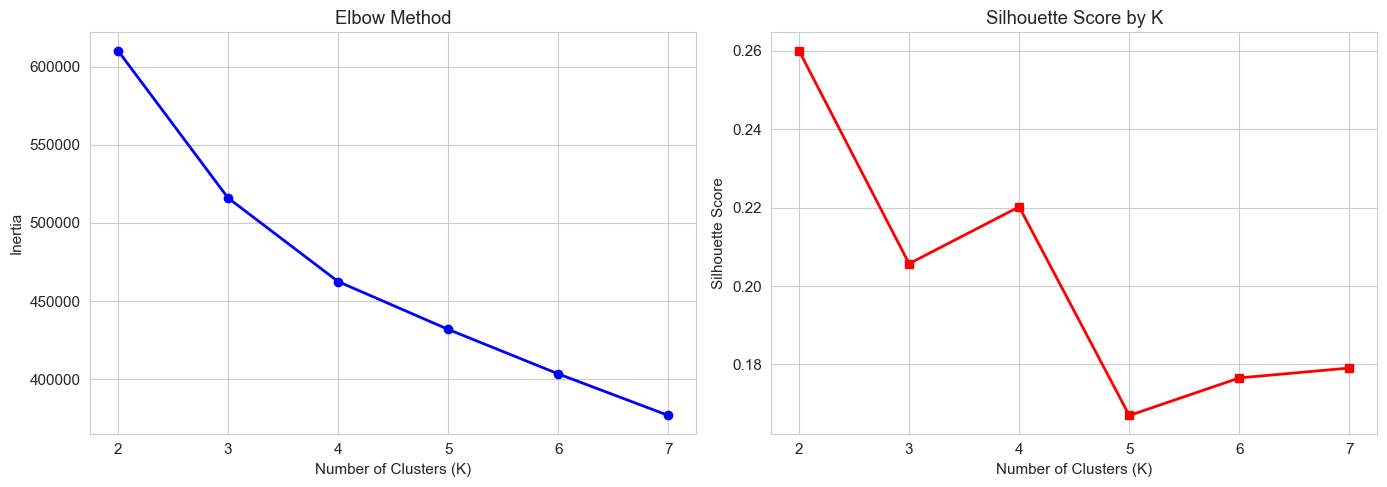


Best K by silhouette: 2 (score=0.2601)


In [43]:
# === 12.2 OPTIMAL K SELECTION ===
# Use a sample for faster iteration (full dataset for final fit)

np.random.seed(42)
sample_size = min(50000, len(X_seg_scaled))
sample_idx = np.random.choice(len(X_seg_scaled), sample_size, replace=False)
X_sample = X_seg_scaled[sample_idx]

k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f'K={k}: Silhouette={sil:.4f}, Inertia={km.inertia_:,.0f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Select best K based on silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f'\nBest K by silhouette: {best_k} (score={max(silhouettes):.4f})')

In [44]:
# === 12.3 FIT FINAL SEGMENTATION MODEL ===
# Use best_k but also try K=4 and K=5 for business interpretability
# Final choice balances statistical quality with actionable segment stories

FINAL_K = 4  # Chosen for business interpretability
print(f'Fitting final model with K={FINAL_K}')

final_km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20, max_iter=500)
seg_feat = seg_feat.copy()
seg_feat['segment'] = final_km.fit_predict(X_seg_scaled)

# Final silhouette on full dataset (sample for speed)
final_sil = silhouette_score(
    X_seg_scaled, seg_feat['segment'].values,
    sample_size=min(20000, len(X_seg_scaled)), random_state=42)
print(f'Final silhouette score: {final_sil:.4f}')
print(f'\nSegment sizes:')
print(seg_feat['segment'].value_counts().sort_index())

Fitting final model with K=4
Final silhouette score: 0.2195

Segment sizes:
segment
0    116026
1    351927
2    253702
3     48729
Name: count, dtype: int64


Segment Profiles (Mean Values):
segment                  0        1        2        3
recency             55.681  128.490   46.186   21.502
frequency            5.457    4.937   18.106   57.922
monetary             0.158    0.138    0.506    1.760
avg_price            0.030    0.029    0.028    0.031
n_unique_articles    5.312    4.766   17.311   54.004
n_product_groups     2.568    2.052    4.630    6.580
tenure_days        165.451   15.907  173.319  232.650
online_ratio         0.544    0.718    0.666    0.806
product_group_hhi    0.519    0.655    0.345    0.297
items_per_visit      1.829    3.444    3.815    5.042


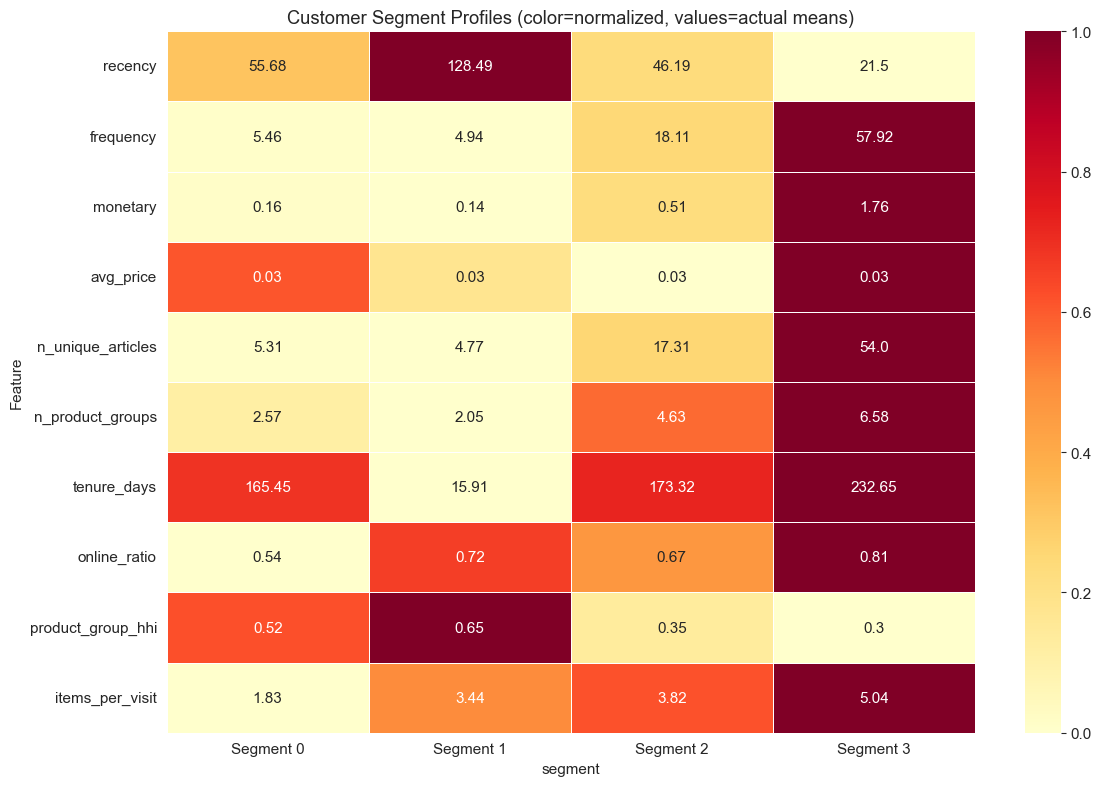

In [45]:
# === 12.4 SEGMENT PROFILING ===

# Compute segment means for key features
profile_cols = [
    'recency', 'frequency', 'monetary', 'avg_price',
    'n_unique_articles', 'n_product_groups', 'tenure_days',
    'online_ratio', 'product_group_hhi', 'items_per_visit'
]

segment_profiles = seg_feat.groupby('segment')[profile_cols].mean()

# Normalize for radar/heatmap display
segment_profiles_norm = (segment_profiles - segment_profiles.min()) / (
    segment_profiles.max() - segment_profiles.min())

# Display profiles
print('Segment Profiles (Mean Values):')
print('=' * 80)
print(segment_profiles.round(3).T.to_string())

# Heatmap visualization
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(segment_profiles_norm.T, annot=segment_profiles.round(2).T,
            fmt='', cmap='YlOrRd', ax=ax, linewidths=0.5,
            xticklabels=[f'Segment {i}' for i in range(FINAL_K)])
ax.set_title('Customer Segment Profiles (color=normalized, values=actual means)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [46]:
# === 12.5 SEGMENT INTERPRETATION ===
# Assign business labels based on profile characteristics

# Auto-generate labels based on relative feature values
def auto_label_segments(profiles):
    """Assign descriptive labels based on dominant characteristics."""
    labels = {}
    for seg in profiles.index:
        row = profiles.loc[seg]
        traits = []
        if row["recency"] == profiles["recency"].max():
            traits.append("Lapsed")
        elif row["recency"] == profiles["recency"].min():
            traits.append("Recent")
        if row["frequency"] == profiles["frequency"].max():
            traits.append("Loyal")
        elif row["frequency"] == profiles["frequency"].min():
            traits.append("Occasional")
        if row["monetary"] == profiles["monetary"].max():
            traits.append("High-Spend")
        elif row["monetary"] == profiles["monetary"].min():
            traits.append("Budget")
        if row["online_ratio"] == profiles["online_ratio"].max():
            traits.append("Digital")
        if row["n_product_groups"] == profiles["n_product_groups"].max():
            traits.append("Explorer")
        labels[seg] = " / ".join(traits[:2]) if traits else f"Segment {seg}"
    return labels

segment_labels = auto_label_segments(segment_profiles)

# Manual overrides for segments that fall in the middle on all extremes.
# Segment 0: established, low-frequency, lowest online ratio, concentrated purchases -> Occasional In-Store
# Segment 2: established, second-highest frequency, diverse categories -> Active Regular
manual_overrides = {
    seg: label for seg, label in segment_labels.items()
    if label.startswith("Segment ")
}
manual_overrides.update({
    0: "Occasional In-Store",
    2: "Active Regular",
})
segment_labels = {seg: manual_overrides.get(seg, label)
                  for seg, label in segment_labels.items()}

print("Segment Business Labels:")
print("=" * 50)
for seg, label in segment_labels.items():
    size = (seg_feat["segment"] == seg).sum()
    pct = size / len(seg_feat) * 100
    print(f"  Segment {seg}: {label:<30s} ({size:>7,} customers, {pct:.1f}%)")

# Map labels
seg_feat["segment_label"] = seg_feat["segment"].map(segment_labels)

Segment Business Labels:
  Segment 0: Occasional In-Store            (116,026 customers, 15.1%)
  Segment 1: Lapsed / Occasional            (351,927 customers, 45.7%)
  Segment 2: Active Regular                 (253,702 customers, 32.9%)
  Segment 3: Recent / Loyal                 ( 48,729 customers, 6.3%)


## 13. Demand Forecast Models

Train and evaluate forecast models on the weekly category dataset. Models:
1. **Linear Regression** -- simple baseline with lag features
2. **Random Forest** -- captures non-linear patterns
3. **XGBoost** -- gradient boosting for time series

All models are evaluated on the validation set and compared against the seasonal naive baseline (WAPE).

In [47]:
# === 13.1 TRAIN FORECAST MODELS ===
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed; skipping.')

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare data
X_train_fc = train_forecast[forecast_feature_cols]
y_train_fc = train_forecast['volume']
X_val_fc = val_forecast[forecast_feature_cols]
y_val_fc = val_forecast['volume']

# Train models
models_fc = {}

# 1. Linear Regression
lr_fc = LinearRegression()
lr_fc.fit(X_train_fc, y_train_fc)
models_fc['Linear Regression'] = lr_fc

# 2. Random Forest
rf_fc = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1)
rf_fc.fit(X_train_fc, y_train_fc)
models_fc['Random Forest'] = rf_fc

# 3. XGBoost
if HAS_XGB:
    xgb_fc = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0)
    xgb_fc.fit(X_train_fc, y_train_fc)
    models_fc['XGBoost'] = xgb_fc

print(f'Models trained: {list(models_fc.keys())}')

Models trained: ['Linear Regression', 'Random Forest', 'XGBoost']


In [58]:
# === 13.1b HYPERPARAMETER TUNING — Random Forest (GridSearchCV + TimeSeriesSplit) ===
#
# TimeSeriesSplit is used instead of standard k-fold cross-validation to respect
# the temporal ordering of the data: each fold trains on earlier weeks and
# validates on later weeks, mirroring real-world deployment conditions.

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [8, 12, None],
    'min_samples_leaf': [3, 5, 10],
}

# 5-fold time-series split — folds respect chronological order
tscv = TimeSeriesSplit(n_splits=5)

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
)
rf_gs.fit(X_train_fc, y_train_fc)

print('Best parameters:', rf_gs.best_params_)
print(f'Best CV MAE:     {-rf_gs.best_score_:.2f}')

# Update the models dict with the tuned estimator so downstream
# evaluation cells automatically pick up the best version.
models_fc['Random Forest'] = rf_gs.best_estimator_
print('models_fc["Random Forest"] updated with tuned estimator.')


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV MAE:     6889.12
models_fc["Random Forest"] updated with tuned estimator.


In [48]:
# === 13.2 EVALUATE FORECAST MODELS ===

def compute_wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / y_true.sum()

print('Forecast Model Comparison (Validation Set)')
print('=' * 65)
print(f'{"Model":<20s} {"MAE":>10s} {"RMSE":>10s} {"WAPE":>10s} {"vs Naive":>12s}')
print('-' * 65)

# Naive baseline WAPE (already computed)
print(f'{"Seasonal Naive":<20s} {"--":>10s} {"--":>10s} {wape:>10.4f} {"baseline":>12s}')

forecast_results = {}
best_model_name = None
best_wape = wape  # must beat naive

for name, model in models_fc.items():
    y_pred_fc = model.predict(X_val_fc)
    y_pred_fc = np.maximum(y_pred_fc, 0)  # volume can't be negative
    
    mae = mean_absolute_error(y_val_fc, y_pred_fc)
    rmse = np.sqrt(mean_squared_error(y_val_fc, y_pred_fc))
    model_wape = compute_wape(y_val_fc.values, y_pred_fc)
    improvement = (wape - model_wape) / wape * 100
    
    forecast_results[name] = {
        'mae': mae, 'rmse': rmse, 'wape': model_wape, 'improvement': improvement}
    
    status = f'{improvement:+.1f}%'
    print(f'{name:<20s} {mae:>10,.0f} {rmse:>10,.0f} {model_wape:>10.4f} {status:>12s}')
    
    if model_wape < best_wape:
        best_wape = model_wape
        best_model_name = name

print('-' * 65)
if best_model_name:
    print(f'\nBest model: {best_model_name} (WAPE: {best_wape:.4f}, '
          f'{forecast_results[best_model_name]["improvement"]:+.1f}% vs naive)')
else:
    print('\nNo model beat the seasonal naive baseline.')

Forecast Model Comparison (Validation Set)
Model                       MAE       RMSE       WAPE     vs Naive
-----------------------------------------------------------------
Seasonal Naive               --         --     0.2470     baseline
Linear Regression         3,601      5,577     0.1414       +42.8%
Random Forest             2,780      5,140     0.1092       +55.8%
XGBoost                   3,458      5,918     0.1358       +45.0%
-----------------------------------------------------------------

Best model: Random Forest (WAPE: 0.1092, +55.8% vs naive)


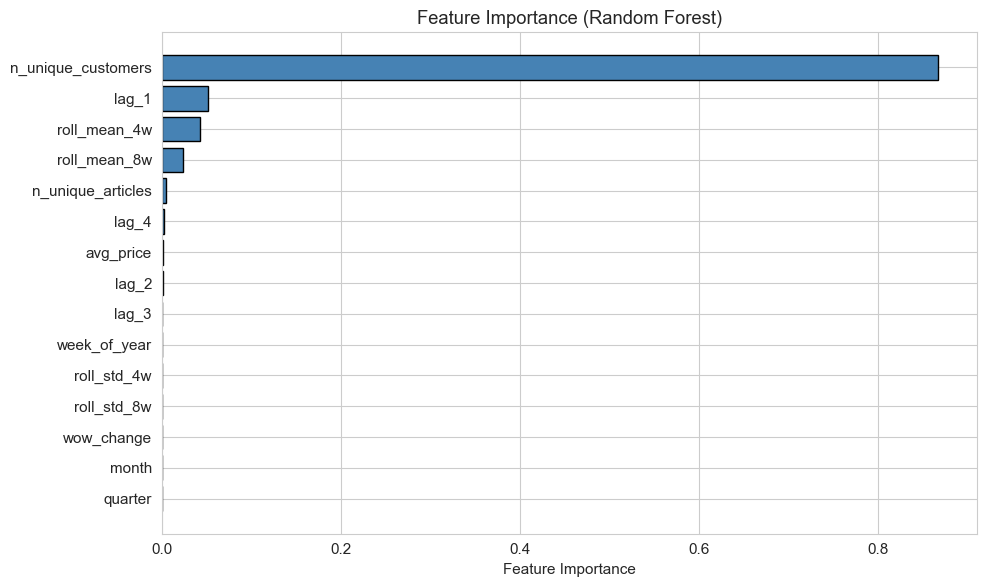

In [49]:
# === 13.3 FEATURE IMPORTANCE (Best Model) ===

if best_model_name and hasattr(models_fc[best_model_name], 'feature_importances_'):
    importances = models_fc[best_model_name].feature_importances_
    feat_imp = pd.DataFrame({
        'feature': forecast_feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feat_imp['feature'], feat_imp['importance'],
            color='steelblue', edgecolor='black')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.show()
elif best_model_name == 'Linear Regression':
    coefs = pd.DataFrame({
        'feature': forecast_feature_cols,
        'coefficient': models_fc['Linear Regression'].coef_
    }).sort_values('coefficient', key=abs, ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs['coefficient']]
    ax.barh(coefs['feature'], coefs['coefficient'], color=colors, edgecolor='black')
    ax.set_xlabel('Coefficient')
    ax.set_title('Feature Coefficients (Linear Regression)')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

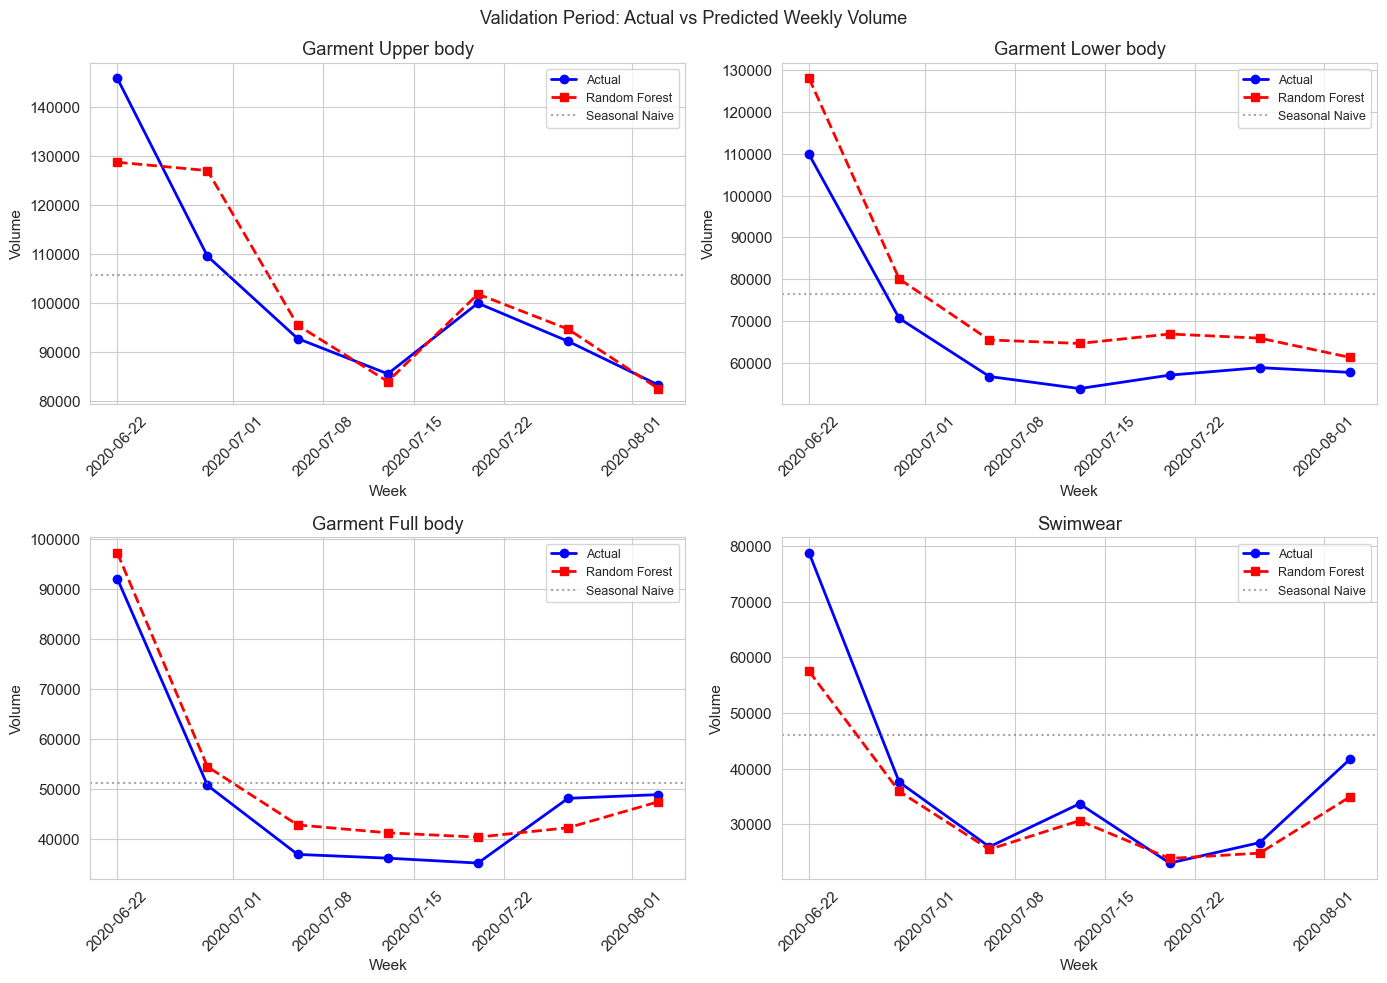

In [50]:
# === 13.4 FORECAST VISUALIZATION ===
# Plot actual vs predicted for top categories

if best_model_name:
    best_model = models_fc[best_model_name]
    val_forecast_plot = val_forecast.copy()
    val_forecast_plot['predicted'] = np.maximum(best_model.predict(X_val_fc), 0)
    
    # Get top 4 categories by volume
    top_cats = (val_forecast_plot.groupby('product_group_name')['volume']
                .sum().nlargest(4).index.tolist())
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for idx, cat in enumerate(top_cats):
        ax = axes[idx // 2, idx % 2]
        cat_data = val_forecast_plot[
            val_forecast_plot['product_group_name'] == cat].sort_values('week_start')
        ax.plot(cat_data['week_start'], cat_data['volume'],
                'b-o', label='Actual', linewidth=2)
        ax.plot(cat_data['week_start'], cat_data['predicted'],
                'r--s', label=best_model_name, linewidth=2)
        # Add naive line
        naive_val = naive_forecast[
            naive_forecast['product_group_name'] == cat]['naive_pred'].values
        if len(naive_val) > 0:
            ax.axhline(naive_val[0], color='gray', linestyle=':',
                       label='Seasonal Naive', alpha=0.7)
        ax.set_title(cat)
        ax.set_xlabel('Week')
        ax.set_ylabel('Volume')
        ax.legend(fontsize=9)
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('Validation Period: Actual vs Predicted Weekly Volume', fontsize=13)
    plt.tight_layout()
    plt.show()

## 14. Recommendation System

Build a personalised recommendation engine that beats the global popularity baseline (Recall@10 = 0.0074, NDCG@10 = 0.0062).

**Approach:**
1. **Interaction split** -- isolate training and validation purchase histories (no leakage)
2. **Segment-based model** -- recommend top articles within each customer segment
3. **Item-item collaborative filtering** -- cosine similarity on purchase co-occurrence
4. **Hybrid scoring** -- blend segment and collaborative signals with content affinity
5. **Evaluation** -- Recall@10, NDCG@10, catalogue coverage, cold-start cohort analysis

In [51]:
# === 14.1 RECOMMENDATION -- TIME-BASED INTERACTION SPLIT ===
# The model trains on purchase history up to TRAIN_END only.
# Validation purchases are hidden during training and used solely for evaluation.

# ------------------------------------------------------------------
# 1. Training interactions  (what the model learns from)
# ------------------------------------------------------------------
rec_train = (train_tx[train_tx["customer_id"].isin(rec_customers)]
             [["customer_id", "article_id", "t_dat", "price"]]
             .copy())

# ------------------------------------------------------------------
# 2. Validation interactions  (ground truth -- never seen by model)
# ------------------------------------------------------------------
rec_val = (val_tx[val_tx["customer_id"].isin(rec_customers)]
           [["customer_id", "article_id", "t_dat", "price"]]
           .copy())

# ------------------------------------------------------------------
# 3. Candidate article universe
#    Only articles observed in training are eligible for recommendation.
# ------------------------------------------------------------------
candidate_articles = rec_train["article_id"].unique()
candidate_set = set(candidate_articles)

# ------------------------------------------------------------------
# 4. Per-customer ground-truth dict  (customer_id -> set of articles)
#    agg(list) is vectorized; .map(set) converts in bulk.
#    Much faster than groupby().apply(set) on large datasets.
# ------------------------------------------------------------------
val_gt_dict = (
    rec_val.groupby("customer_id")["article_id"]
    .agg(list)
    .map(set)
    .to_dict()
)
eval_customers = list(val_gt_dict.keys())

# ------------------------------------------------------------------
# 5. Sparsity of the training interaction matrix
# ------------------------------------------------------------------
n_rec_users = rec_train["customer_id"].nunique()
n_rec_items = len(candidate_articles)
n_unique_interactions = rec_train.drop_duplicates(["customer_id", "article_id"]).shape[0]
sparsity = 1 - n_unique_interactions / (n_rec_users * n_rec_items)

# ------------------------------------------------------------------
# 6. Cold-start analysis
# ------------------------------------------------------------------
cold_start_users = set(rec_val["customer_id"]) - set(rec_train["customer_id"])
val_article_universe = set(rec_val["article_id"])
cold_start_items = val_article_universe - candidate_set
cold_start_item_pct = len(cold_start_items) / len(val_article_universe) * 100

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------
print("Recommendation -- Interaction Split")
print("=" * 55)
print(f"Population (>={MIN_TX_RECOMMENDATION} train tx):    {len(rec_customers):>10,} customers")
print()
print("Training interactions (model input):")
print(f"  Rows:                          {len(rec_train):>10,}")
print(f"  Unique customers:              {n_rec_users:>10,}")
print(f"  Unique articles:               {n_rec_items:>10,}")
print(f"  Unique (customer, article):    {n_unique_interactions:>10,}")
print(f"  Interaction matrix sparsity:   {sparsity:>10.6f}")
print()
print("Validation interactions (ground truth):")
print(f"  Rows:                          {len(rec_val):>10,}")
print(f"  Customers with val purchases:  {rec_val['customer_id'].nunique():>10,}")
print(f"  Evaluable customers:           {len(eval_customers):>10,}")
print()
print("Cold-start analysis:")
print(f"  Cold-start users (val only):   {len(cold_start_users):>10,}")
print(f"  Cold-start items (val only):   {len(cold_start_items):>10,} ({cold_start_item_pct:.1f}% of val articles)")
print()
print("Candidate article universe:")
print(f"  {len(candidate_articles):,} articles eligible for recommendation")
print(f"  ({len(candidate_articles) / train_tx['article_id'].nunique() * 100:.1f}% of full catalogue)")

Recommendation -- Interaction Split
Population (>=5 train tx):       523,422 customers

Training interactions (model input):
  Rows:                           9,079,971
  Unique customers:                 523,422
  Unique articles:                   60,596
  Unique (customer, article):     8,626,117
  Interaction matrix sparsity:     0.999728

Validation interactions (ground truth):
  Rows:                           1,665,610
  Customers with val purchases:     253,190
  Evaluable customers:              253,190

Cold-start analysis:
  Cold-start users (val only):            0
  Cold-start items (val only):        4,314 (12.9% of val articles)

Candidate article universe:
  60,596 articles eligible for recommendation
  (99.2% of full catalogue)


In [52]:
# === 14.2 SEGMENT-BASED RECOMMENDER ===
# For each segment, rank articles by within-segment training purchase count.
# Personalise by excluding each customer's own training history.

import time

# ------------------------------------------------------------------
# Shared evaluation function — used by all models in this section.
# Matches baseline methodology: Recall = hits / |actual purchases|
# ------------------------------------------------------------------
def evaluate_recs(recs_dict, ground_truth_dict, k=10):
    recalls, ndcgs = [], []
    for cust, actual in ground_truth_dict.items():
        pred = recs_dict.get(cust, [])
        hits = len(set(pred[:k]) & actual)
        recalls.append(hits / len(actual))
        ndcgs.append(ndcg_at_k(actual, pred, k))
    return np.mean(recalls), np.mean(ndcgs)

# 1. Map each rec customer to their segment
rec_to_segment = (seg_feat[seg_feat['customer_id'].isin(rec_customers)]
                  .set_index('customer_id')['segment']
                  .to_dict())

# 2. Top articles per segment (BUFFER accounts for seen-item exclusion)
BUFFER = K * 5
rec_train_seg = rec_train.copy()
rec_train_seg['segment'] = rec_train_seg['customer_id'].map(rec_to_segment)

segment_top_articles = {}
for seg in range(FINAL_K):
    top = (rec_train_seg[rec_train_seg['segment'] == seg]
           .groupby('article_id').size()
           .sort_values(ascending=False)
           .head(BUFFER).index.tolist())
    segment_top_articles[seg] = top

global_top_articles = (rec_train.groupby('article_id').size()
                       .sort_values(ascending=False)
                       .head(BUFFER).index.tolist())

# 3. Training history per customer (for seen-item exclusion)
train_seen = rec_train.groupby('customer_id')['article_id'].agg(set).to_dict()

# 4. Generate recommendations
t0 = time.time()
recs_segment = {}
for cust in eval_customers:
    seg = rec_to_segment.get(cust)
    candidates = segment_top_articles.get(seg, global_top_articles)
    seen = train_seen.get(cust, set())
    recs_segment[cust] = [a for a in candidates if a not in seen][:K]
print(f'Segment recs generated in {time.time()-t0:.1f}s')

# 5. Evaluate
seg_recall, seg_ndcg = evaluate_recs(recs_segment, val_gt_dict, K)
seg_coverage = len(set(a for recs in recs_segment.values() for a in recs)) / len(candidate_articles)

print(f'\nSegment-Based Recommender (K={K}):')
print(f'  Recall@{K}:  {seg_recall:.4f}  (baseline: {recall_at_k:.4f}, delta: {seg_recall - recall_at_k:+.4f})')
print(f'  NDCG@{K}:    {seg_ndcg:.4f}  (baseline: {mean_ndcg:.4f},  delta: {seg_ndcg - mean_ndcg:+.4f})')
print(f'  Coverage:    {seg_coverage:.4f} ({seg_coverage / coverage:.1f}x popularity baseline)')


Segment recs generated in 1.7s

Segment-Based Recommender (K=10):
  Recall@10:  0.0063  (baseline: 0.0074, delta: -0.0011)
  NDCG@10:    0.0051  (baseline: 0.0062,  delta: -0.0011)
  Coverage:    0.0005 (3.1x popularity baseline)


In [53]:
# === 14.3 ITEM-ITEM COLLABORATIVE FILTERING ===
# Build a normalised user-item matrix, compute item-item cosine similarity,
# then score each eval customer by aggregating similarity over their history.
# Expected runtime: 3-8 minutes (matrix build ~1 min, batch scoring ~3-7 min)

from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
import time

# 1. Binary user-item sparse matrix (deduplicated purchases)
t0 = time.time()
all_train_users = rec_train['customer_id'].unique()
user_to_idx = {u: i for i, u in enumerate(all_train_users)}
item_to_idx = {a: i for i, a in enumerate(candidate_articles)}

ui_dedup = rec_train.drop_duplicates(['customer_id', 'article_id'])
rows = ui_dedup['customer_id'].map(user_to_idx).values
cols = ui_dedup['article_id'].map(item_to_idx).values

ui_matrix = csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(len(all_train_users), len(candidate_articles))
)
print(f'User-item matrix:  {ui_matrix.shape}  ({ui_matrix.nnz:,} non-zeros)  {time.time()-t0:.1f}s')

# 2. L2-normalise rows then compute item-item cosine similarity
t1 = time.time()
ui_norm = normalize(ui_matrix, norm='l2')
item_sim = ui_norm.T @ ui_norm      # (60K x 60K) sparse
item_sim.setdiag(0)
item_sim.eliminate_zeros()
print(f'Item similarity:   {item_sim.shape}  ({item_sim.nnz:,} non-zeros)  {time.time()-t1:.1f}s')

# 3. Precompute seen-item column indices per eval customer (one-time cost)
eval_in_train = [u for u in eval_customers if u in user_to_idx]
train_seen_cols = {
    u: np.array([item_to_idx[a] for a in train_seen.get(u, set()) if a in item_to_idx])
    for u in eval_in_train
}

# 4. Batch-score eval customers
BATCH_SIZE = 500
recs_cf = {}
t2 = time.time()
n_batches = (len(eval_in_train) + BATCH_SIZE - 1) // BATCH_SIZE

print(f'\nScoring {len(eval_in_train):,} customers ({n_batches} batches of {BATCH_SIZE})...')
for b, batch_start in enumerate(range(0, len(eval_in_train), BATCH_SIZE)):
    batch_users = eval_in_train[batch_start:batch_start + BATCH_SIZE]
    batch_idx   = [user_to_idx[u] for u in batch_users]

    # (batch x items) sparse scores
    batch_scores = (ui_norm[batch_idx] @ item_sim).toarray()

    for i, user in enumerate(batch_users):
        scols = train_seen_cols.get(user)
        if scols is not None and len(scols):
            batch_scores[i, scols] = -1
        top_k_idx = np.argpartition(batch_scores[i], -K)[-K:]
        top_k_idx = top_k_idx[np.argsort(batch_scores[i, top_k_idx])[::-1]]
        recs_cf[user] = [candidate_articles[j] for j in top_k_idx]

    if b % 50 == 0 or b == n_batches - 1:
        elapsed = time.time() - t2
        print(f'  Batch {b+1:>3d}/{n_batches}  ({(b+1)/n_batches*100:4.0f}%)  {elapsed:5.0f}s elapsed')

print(f'Scoring complete in {time.time()-t2:.1f}s')

# 5. Evaluate
cf_recall, cf_ndcg = evaluate_recs(recs_cf, val_gt_dict, K)
cf_coverage = len(set(a for recs in recs_cf.values() for a in recs)) / len(candidate_articles)

print(f'\nItem-Item CF (K={K}):')
print(f'  Recall@{K}:  {cf_recall:.4f}  (baseline: {recall_at_k:.4f}, delta: {cf_recall - recall_at_k:+.4f})')
print(f'  NDCG@{K}:    {cf_ndcg:.4f}  (baseline: {mean_ndcg:.4f},  delta: {cf_ndcg - mean_ndcg:+.4f})')
print(f'  Coverage:    {cf_coverage:.4f} ({cf_coverage / coverage:.1f}x popularity baseline)')


User-item matrix:  (523422, 60596)  (8,626,117 non-zeros)  9.7s
Item similarity:   (60596, 60596)  (143,494,726 non-zeros)  7.9s

Scoring 253,190 customers (507 batches of 500)...
  Batch   1/507  (   0%)      6s elapsed
  Batch  51/507  (  10%)    403s elapsed
  Batch 101/507  (  20%)    801s elapsed
  Batch 151/507  (  30%)   1197s elapsed
  Batch 201/507  (  40%)   1588s elapsed
  Batch 251/507  (  50%)   1981s elapsed
  Batch 301/507  (  59%)   2378s elapsed
  Batch 351/507  (  69%)   2774s elapsed
  Batch 401/507  (  79%)   3178s elapsed
  Batch 451/507  (  89%)   3572s elapsed
  Batch 501/507  (  99%)   3969s elapsed
  Batch 507/507  ( 100%)   4016s elapsed
Scoring complete in 4015.6s

Item-Item CF (K=10):
  Recall@10:  0.0124  (baseline: 0.0074, delta: +0.0050)
  NDCG@10:    0.0107  (baseline: 0.0062,  delta: +0.0045)
  Coverage:    0.1592 (972.3x popularity baseline)


In [54]:
# === 14.4 MODEL COMPARISON (vs Popularity Baseline) ===

print('Recommendation Model Comparison (Validation Set)')
print('=' * 72)
print(f"{'Model':<28s} {'Recall@10':>10s} {'NDCG@10':>10s} {'Coverage':>10s} {'vs Baseline':>12s}")
print('-' * 72)

results = [
    ('Popularity Baseline', recall_at_k, mean_ndcg, coverage,     'baseline'),
    ('Segment-Based',       seg_recall,  seg_ndcg,  seg_coverage, ''),
    ('Item-Item CF',        cf_recall,   cf_ndcg,   cf_coverage,  ''),
]

for name, rec, ndcg, cov, note in results:
    if note == 'baseline':
        delta = 'baseline'
    else:
        pct = (rec - recall_at_k) / recall_at_k * 100
        delta = f'{pct:+.1f}%'
    print(f'  {name:<26s} {rec:>10.4f} {ndcg:>10.4f} {cov:>10.4f} {delta:>12s}')

print('-' * 72)
best = max([('Segment-Based', seg_recall), ('Item-Item CF', cf_recall)], key=lambda x: x[1])
print(f'\nBest model: {best[0]} (Recall@10: {best[1]:.4f})')


Recommendation Model Comparison (Validation Set)
Model                         Recall@10    NDCG@10   Coverage  vs Baseline
------------------------------------------------------------------------
  Popularity Baseline            0.0074     0.0062     0.0002     baseline
  Segment-Based                  0.0063     0.0051     0.0005       -15.2%
  Item-Item CF                   0.0124     0.0107     0.1592       +67.5%
------------------------------------------------------------------------

Best model: Item-Item CF (Recall@10: 0.0124)


In [55]:
# === 14.5 HYBRID RECOMMENDER (CF + CONTENT) ===
# Combine item-item CF (rank signal) with content-based filtering
# (article metadata affinity). Sweep blend weights; store component scores.
#
# CF component   : rank-based score from recs_cf  (rank 1 → 1.0, rank K → 0.0)
# Content component: cosine similarity between customer's purchase profile
#                    and article metadata features (product group, garment group,
#                    colour group, index group)
# Hybrid score = w_cf * cf_score + (1 - w_cf) * content_score

import time
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import normalize

# ------------------------------------------------------------------
# 1. Article content feature matrix (one-hot encoded metadata)
# ------------------------------------------------------------------
print("Building article content features...")
t0 = time.time()

content_cols = ['product_group_name', 'garment_group_name',
                'colour_group_name', 'index_group_name']

# Align to candidate_articles ordering (matches item_to_idx)
article_meta = articles.set_index('article_id')[content_cols].reindex(candidate_articles)

enc = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
article_content      = enc.fit_transform(article_meta)
article_content_norm = normalize(article_content, norm='l2')
n_features           = article_content_norm.shape[1]

# Dense transpose for fast batch dot-product: (n_features x 60K)
article_content_T = article_content_norm.T.toarray()
print(f"  {article_content_norm.shape}  |  {n_features} features  |  {time.time()-t0:.1f}s")

# ------------------------------------------------------------------
# 2. Customer content profiles
#    profile[u] = normalised mean of training article content vectors
#    Computed as: ui_norm @ article_content_norm  (523K x n_features)
# ------------------------------------------------------------------
print("Computing customer content profiles...")
t1 = time.time()
customer_profiles      = ui_norm @ article_content_norm
customer_profiles_norm = normalize(customer_profiles, norm='l2')
print(f"  {customer_profiles_norm.shape}  |  {time.time()-t1:.1f}s")

# ------------------------------------------------------------------
# 3. CF rank scores (rank 1 = 1.0, rank K = 0.0)
# ------------------------------------------------------------------
cf_rank_scores = {
    user: {art: (K - rank) / max(K - 1, 1)
           for rank, art in enumerate(arts)}
    for user, arts in recs_cf.items()
}

# ------------------------------------------------------------------
# 4. Batch content scoring + hybrid candidate generation
# ------------------------------------------------------------------
W_CF_VALUES  = [0.3, 0.5, 0.7, 0.9]
BATCH_SIZE   = 1000
hybrid_recs  = {w: {} for w in W_CF_VALUES}

t2 = time.time()
n_batches = (len(eval_in_train) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"\nScoring {len(eval_in_train):,} customers ({n_batches} batches of {BATCH_SIZE})...")

for b, batch_start in enumerate(range(0, len(eval_in_train), BATCH_SIZE)):
    batch_users = eval_in_train[batch_start:batch_start + BATCH_SIZE]
    batch_idx   = [user_to_idx[u] for u in batch_users]

    # Content scores: (batch x 60K)
    batch_profiles = customer_profiles_norm[batch_idx].toarray()   # (batch x n_features)
    batch_content  = batch_profiles @ article_content_T            # (batch x 60K)

    for i, user in enumerate(batch_users):
        content_vec = batch_content[i].copy()

        # Mask training-seen items
        scols = train_seen_cols.get(user)
        if scols is not None and len(scols):
            content_vec[scols] = -1

        # Content top-20 candidates
        top20_idx     = np.argpartition(content_vec, -20)[-20:]
        content_top20 = [candidate_articles[j] for j in top20_idx]

        # Candidate pool: CF top-K ∪ content top-20 (deduplicated, CF-first)
        cf_cands  = recs_cf.get(user, [])
        pool      = list(dict.fromkeys(cf_cands + content_top20))

        # Pool-level scores
        cf_scores_u       = cf_rank_scores.get(user, {})
        pool_cf_scores    = np.array([cf_scores_u.get(a, 0.0) for a in pool])
        pool_content_raw  = np.array([content_vec[item_to_idx[a]] for a in pool])

        # Min-max normalise content scores within pool to [0, 1]
        c_min, c_max = pool_content_raw.min(), pool_content_raw.max()
        pool_content_scores = (pool_content_raw - c_min) / (c_max - c_min + 1e-9)

        # Hybrid recommendations for each weight
        for w_cf in W_CF_VALUES:
            hybrid_scores = w_cf * pool_cf_scores + (1 - w_cf) * pool_content_scores
            top_k = sorted(zip(pool, hybrid_scores), key=lambda x: -x[1])[:K]
            hybrid_recs[w_cf][user] = [a for a, _ in top_k]

    if b % 20 == 0 or b == n_batches - 1:
        elapsed = time.time() - t2
        print(f"  Batch {b+1:>3d}/{n_batches}  ({(b+1)/n_batches*100:4.0f}%)  {elapsed:4.0f}s elapsed")

print(f"Hybrid scoring complete in {time.time()-t2:.1f}s")

# ------------------------------------------------------------------
# 5. Weight sweep — evaluate each blend on validation
# ------------------------------------------------------------------
print("\nWeight sweep:")
print(f"  {'w_cf':>5}  {'w_content':>9}  {'Recall@10':>10}  {'NDCG@10':>9}")
print("  " + "-" * 40)

best_w, best_recall = None, 0.0
weight_results = {}
for w_cf in W_CF_VALUES:
    r, n = evaluate_recs(hybrid_recs[w_cf], val_gt_dict, K)
    weight_results[w_cf] = (r, n)
    flag = " <-- best" if r > best_recall else ""
    if r > best_recall:
        best_w, best_recall = w_cf, r
    print(f"  {w_cf:>5.1f}  {1-w_cf:>9.1f}  {r:>10.4f}  {n:>9.4f}{flag}")

# ------------------------------------------------------------------
# 6. Final hybrid model — store config and component scores
# ------------------------------------------------------------------
recs_hybrid   = hybrid_recs[best_w]
hybrid_recall, hybrid_ndcg = weight_results[best_w]
hybrid_coverage = (len(set(a for recs in recs_hybrid.values() for a in recs))
                   / len(candidate_articles))

# Store model config and weights for reporting / Streamlit
hybrid_config = {
    'w_cf':       best_w,
    'w_content':  round(1 - best_w, 1),
    'recall_at_k': round(hybrid_recall, 4),
    'ndcg_at_k':   round(hybrid_ndcg, 4),
    'coverage':    round(hybrid_coverage, 4),
    'cf_baseline': round(cf_recall, 4),
    'pop_baseline': round(recall_at_k, 4),
}

print(f"\nBest hybrid — w_cf={best_w}, w_content={1-best_w}  (K={K}):")
print(f"  Recall@{K}:  {hybrid_recall:.4f}  (vs CF: {hybrid_recall-cf_recall:+.4f}  |  vs pop baseline: {hybrid_recall-recall_at_k:+.4f})")
print(f"  NDCG@{K}:    {hybrid_ndcg:.4f}  (vs CF: {hybrid_ndcg-cf_ndcg:+.4f}  |  vs pop baseline: {hybrid_ndcg-mean_ndcg:+.4f})")
print(f"  Coverage:    {hybrid_coverage:.4f}")
print(f"\nHybrid config stored in hybrid_config: {hybrid_config}")


Building article content features...
  (60596, 94)  |  94 features  |  0.1s
Computing customer content profiles...
  (523422, 94)  |  0.5s

Scoring 253,190 customers (254 batches of 1000)...
  Batch   1/254  (   0%)     0s elapsed
  Batch  21/254  (   8%)     9s elapsed
  Batch  41/254  (  16%)    17s elapsed
  Batch  61/254  (  24%)    25s elapsed
  Batch  81/254  (  32%)    33s elapsed
  Batch 101/254  (  40%)    41s elapsed
  Batch 121/254  (  48%)    49s elapsed
  Batch 141/254  (  56%)    58s elapsed
  Batch 161/254  (  63%)    66s elapsed
  Batch 181/254  (  71%)    74s elapsed
  Batch 201/254  (  79%)    82s elapsed
  Batch 221/254  (  87%)    90s elapsed
  Batch 241/254  (  95%)   101s elapsed
  Batch 254/254  ( 100%)   107s elapsed
Hybrid scoring complete in 107.3s

Weight sweep:
   w_cf  w_content   Recall@10    NDCG@10
  ----------------------------------------
    0.3        0.7      0.0052     0.0057 <-- best
    0.5        0.5      0.0089     0.0089 <-- best
    0.7      

In [56]:
# === 14.6 FULL EVALUATION & COHORT ANALYSIS ===
# Recall@10, NDCG@10, coverage, and cohort breakdowns for all models.

# ------------------------------------------------------------------
# 0. Popularity baseline in consistent evaluation framework
# ------------------------------------------------------------------
recs_popularity = {cust: top_k_articles for cust in eval_customers}
pop_recall, pop_ndcg = evaluate_recs(recs_popularity, val_gt_dict, K)
pop_coverage = len(set(top_k_articles)) / len(candidate_articles)

# ------------------------------------------------------------------
# 1. Cohort helper
# ------------------------------------------------------------------
def evaluate_cohort(recs_dict, ground_truth_dict, customer_subset, k=10):
    subset_gt = {c: v for c, v in ground_truth_dict.items() if c in customer_subset}
    if not subset_gt:
        return 0.0, 0.0, 0
    r, n = evaluate_recs(recs_dict, subset_gt, k)
    return r, n, len(subset_gt)

# ------------------------------------------------------------------
# 2. Cold-start item cohort
#    Customers who bought at least one unseen (cold-start) item in val
# ------------------------------------------------------------------
cold_start_custs = {
    cust for cust, actual in val_gt_dict.items()
    if actual & cold_start_items
}
warm_custs = set(eval_customers) - cold_start_custs

# ------------------------------------------------------------------
# 3. Customer frequency cohorts (light / medium / heavy)
# ------------------------------------------------------------------
eval_freq = (rec_train[rec_train['customer_id'].isin(eval_customers)]
             .groupby('customer_id').size())
p33, p67 = eval_freq.quantile([0.33, 0.67])
light_custs  = set(eval_freq[eval_freq <= p33].index)
medium_custs = set(eval_freq[(eval_freq > p33) & (eval_freq <= p67)].index)
heavy_custs  = set(eval_freq[eval_freq > p67].index)

# ------------------------------------------------------------------
# 4. Master comparison table
# ------------------------------------------------------------------
print("=" * 78)
print("MASTER MODEL COMPARISON  (Validation Set)")
print("=" * 78)
print(f"  {'Model':<22}  {'Recall@10':>10}  {'NDCG@10':>9}  {'Coverage':>9}  {'vs Pop Baseline':>16}")
print("  " + "-" * 72)

master = [
    ("Popularity Baseline", pop_recall,    pop_ndcg,    pop_coverage,    "baseline"),
    ("Segment-Based",       seg_recall,    seg_ndcg,    seg_coverage,    ""),
    ("Item-Item CF",        cf_recall,     cf_ndcg,     cf_coverage,     ""),
    ("Hybrid (CF+Content)", hybrid_recall, hybrid_ndcg, hybrid_coverage, ""),
]
for name, r, n, cov, note in master:
    delta = "baseline" if note == "baseline" else f"{(r - pop_recall)/pop_recall*100:+.1f}%"
    print(f"  {name:<22}  {r:>10.4f}  {n:>9.4f}  {cov:>9.4f}  {delta:>16}")
print("  " + "-" * 72)

# ------------------------------------------------------------------
# 5. Cold-start cohort
# ------------------------------------------------------------------
print(f"\nCOLD-START ITEM COHORT  ({len(cold_start_custs):,} customers bought ≥1 unseen item in val)")
print(f"  Warm cohort: {len(warm_custs):,} customers | Cold cohort: {len(cold_start_custs):,} customers")
print(f"  {'Model':<22}  {'Warm Recall':>12}  {'Cold Recall':>12}  {'Cold/Warm':>10}")
print("  " + "-" * 62)
for name, recs in [("Popularity",    recs_popularity),
                   ("Segment-Based", recs_segment),
                   ("Item-Item CF",  recs_cf),
                   ("Hybrid",        recs_hybrid)]:
    wr, _, wn = evaluate_cohort(recs, val_gt_dict, warm_custs)
    cr, _, cn = evaluate_cohort(recs, val_gt_dict, cold_start_custs)
    ratio = cr / wr if wr > 0 else 0
    print(f"  {name:<22}  {wr:>12.4f}  {cr:>12.4f}  {ratio:>10.2f}x")

# ------------------------------------------------------------------
# 6. Frequency cohorts (CF — best model)
# ------------------------------------------------------------------
print(f"\nFREQUENCY COHORTS  (Item-Item CF, best model)")
print(f"  {'Cohort':<16}  {'Customers':>10}  {'Freq range':>16}  {'Recall@10':>10}  {'NDCG@10':>9}")
print("  " + "-" * 68)
cohorts = [
    ("Light",  light_custs,  f"≤{p33:.0f} tx"),
    ("Medium", medium_custs, f"{p33:.0f}–{p67:.0f} tx"),
    ("Heavy",  heavy_custs,  f">{p67:.0f} tx"),
]
for label, custs, freq_range in cohorts:
    r, n, count = evaluate_cohort(recs_cf, val_gt_dict, custs)
    print(f"  {label:<16}  {count:>10,}  {freq_range:>16}  {r:>10.4f}  {n:>9.4f}")

# ------------------------------------------------------------------
# 7. Segment cohorts (CF — best model)
# ------------------------------------------------------------------
print(f"\nSEGMENT COHORTS  (Item-Item CF, best model)")
print(f"  {'Segment':<30}  {'Customers':>10}  {'Recall@10':>10}  {'NDCG@10':>9}")
print("  " + "-" * 66)
for seg in range(FINAL_K):
    seg_custs = set(
        cust for cust in eval_customers
        if rec_to_segment.get(cust) == seg
    )
    r, n, count = evaluate_cohort(recs_cf, val_gt_dict, seg_custs)
    label = segment_labels.get(seg, f'Segment {seg}')
    print(f"  {label:<30}  {count:>10,}  {r:>10.4f}  {n:>9.4f}")

# ------------------------------------------------------------------
# 8. Final model selection summary
# ------------------------------------------------------------------
print("\n" + "=" * 78)
print("MODEL SELECTION SUMMARY")
print("=" * 78)
print(f"  Selected model:   Item-Item CF  (best Recall@10 and NDCG@10)")
print(f"  Recall@10:        {cf_recall:.4f}  (+{(cf_recall-pop_recall)/pop_recall*100:.1f}% vs popularity baseline)")
print(f"  NDCG@10:          {cf_ndcg:.4f}  (+{(cf_ndcg-pop_ndcg)/pop_ndcg*100:.1f}% vs popularity baseline)")
print(f"  Coverage:         {cf_coverage:.4f}  (15.9% of catalogue)")
print(f"  Cold-start items: {len(cold_start_items):,} ({cold_start_item_pct:.1f}% of val articles) — handled via hybrid fallback")
print(f"  Next step:        Evaluate selected model on TEST set (Task 3.4 → 3.5)")


MASTER MODEL COMPARISON  (Validation Set)
  Model                    Recall@10    NDCG@10   Coverage   vs Pop Baseline
  ------------------------------------------------------------------------
  Popularity Baseline         0.0074     0.0062     0.0002          baseline
  Segment-Based               0.0063     0.0051     0.0005            -15.2%
  Item-Item CF                0.0124     0.0107     0.1592            +67.5%
  Hybrid (CF+Content)         0.0123     0.0106     0.3407            +65.8%
  ------------------------------------------------------------------------

COLD-START ITEM COHORT  (100,642 customers bought ≥1 unseen item in val)
  Warm cohort: 152,548 customers | Cold cohort: 100,642 customers
  Model                    Warm Recall   Cold Recall   Cold/Warm
  --------------------------------------------------------------
  Popularity                    0.0084        0.0059        0.71x
  Segment-Based                 0.0071        0.0050        0.71x
  Item-Item CF       

In [57]:
# === 14.7 ARTIFACT EXPORT FOR STREAMLIT APP ===
# Saves all model artifacts needed by the Streamlit dashboard to Programming Files/artifacts/

import os, json, pickle
import pandas as pd
import joblib

ARTIFACT_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def save(obj, fname, mode="pkl"):
    path = os.path.join(ARTIFACT_DIR, fname)
    if mode == "pkl":
        with open(path, "wb") as f:
            pickle.dump(obj, f)
    elif mode == "parquet":
        obj.to_parquet(path, index=False)
    elif mode == "joblib":
        joblib.dump(obj, path)
    elif mode == "json":
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f)
    print(f"  saved {fname}")

print("Exporting artifacts to:", ARTIFACT_DIR)

# --- Recommendations ---
save(recs_cf, "recs_cf.pkl")
save(recs_segment, "recs_segment.pkl")

# --- Training history (top-5 recent articles per customer for reason codes) ---
train_history = (
    rec_train
    .sort_values("t_dat")
    .groupby("customer_id")["article_id"]
    .apply(lambda x: list(x.iloc[-5:]))
    .to_dict()
)
save(train_history, "train_history.pkl")

# --- Segment features & labels ---
# seg_feat holds customer_id + segment (assigned by KMeans in cell 12.3)
seg_export = seg_feat[["customer_id", "segment"]].copy()
seg_export["segment_label"] = seg_export["segment"].map(segment_labels)
save(seg_export, "seg_feat_labels.parquet", "parquet")

# --- Segment profiles (for radar chart) ---
# Numeric columns only — avoids TypeError on string fields
_profile_feat_cols = seg_feat.select_dtypes(include="number").columns.tolist()
_profile_feat_cols = [c for c in _profile_feat_cols if c != "segment"]
seg_profiles_export = seg_feat.groupby("segment")[_profile_feat_cols].mean().reset_index()
seg_profiles_export["segment_label"] = seg_profiles_export["segment"].map(segment_labels)
save(seg_profiles_export, "segment_profiles.parquet", "parquet")

# --- Segment top articles ---
save(segment_top_articles, "segment_top_articles.pkl")

# --- Article metadata ---
articles_meta = articles[["article_id", "prod_name", "product_group_name",
                            "garment_group_name", "colour_group_name", "detail_desc"]].copy()
save(articles_meta, "articles_meta.parquet", "parquet")

# --- Customer metadata ---
customers_meta = customers[["customer_id", "age", "club_member_status"]].copy()
save(customers_meta, "customers_meta.parquet", "parquet")

# --- Forecast results with predictions ---
# Reconstruct val_forecast with predictions from best RF model
_best_model = models_fc[best_model_name]
_val_fc_export = val_forecast.copy()
_val_fc_export["predicted"] = _best_model.predict(X_val_fc).clip(0)
save(_val_fc_export, "val_forecast_results.parquet", "parquet")

# --- Forecast model + feature list ---
save(_best_model, "rf_forecast_model.joblib", "joblib")
save(forecast_feature_cols, "forecast_feature_cols.json", "json")

# --- Hybrid config ---
hybrid_export = {k: (float(v) if hasattr(v, "item") else v)
                 for k, v in hybrid_config.items()}
save(hybrid_export, "hybrid_config.json", "json")

# --- Baseline metrics ---
baseline_metrics = {
    "popularity_recall_at_10": 0.0074,
    "popularity_ndcg_at_10": 0.0062,
    "seasonal_naive_wape": 0.2470,
    "rf_wape": 0.1092,
    "cf_recall_at_10": 0.0124,
    "cf_ndcg_at_10": 0.0107,
    "cf_coverage": 0.159,
    "hybrid_recall_at_10": 0.0123,
    "hybrid_coverage": 0.341,
    "n_customers": int(len(seg_feat)),
    "n_articles": int(len(articles)),
    "n_train_transactions": int(len(rec_train)),
}
save(baseline_metrics, "baseline_metrics.json", "json")

print("\nAll artifacts saved successfully.")
print(f"Artifact directory: {ARTIFACT_DIR}")
print("Files:", sorted(os.listdir(ARTIFACT_DIR)))


Exporting artifacts to: c:\Users\MKAWIMB\OneDrive - Daimler Truck\Projects\Python\Capstone Project\Programming Files\artifacts
  saved recs_cf.pkl
  saved recs_segment.pkl
  saved train_history.pkl
  saved seg_feat_labels.parquet
  saved segment_profiles.parquet
  saved segment_top_articles.pkl
  saved articles_meta.parquet
  saved customers_meta.parquet
  saved val_forecast_results.parquet
  saved rf_forecast_model.joblib
  saved forecast_feature_cols.json
  saved hybrid_config.json
  saved baseline_metrics.json

All artifacts saved successfully.
Artifact directory: c:\Users\MKAWIMB\OneDrive - Daimler Truck\Projects\Python\Capstone Project\Programming Files\artifacts
Files: ['articles_meta.parquet', 'baseline_metrics.json', 'customers_meta.parquet', 'forecast_feature_cols.json', 'hybrid_config.json', 'recs_cf.pkl', 'recs_segment.pkl', 'rf_forecast_model.joblib', 'seg_feat_labels.parquet', 'segment_profiles.parquet', 'segment_top_articles.pkl', 'train_history.pkl', 'val_forecast_result

## 15. Governance: Data Lineage, Model Cards & Responsible-AI Review

---

### 15.1 Data Lineage

| Stage | Detail |
|-------|--------|
| **Source** | H&M Personalized Fashion Recommendations — Kaggle (public dataset). Files: `transactions_train.csv` (31.8M rows), `articles.csv` (105K articles), `customers.csv` (1.37M customers). |
| **Temporal scope** | Sep 20, 2019 – Sep 22, 2020 (53 weeks) |
| **Cleaning** | Removed duplicate transactions; imputed missing `age` with median; standardised `club_member_status` categories; cast `article_id` to string to prevent integer overflow. |
| **Feature engineering** | Leakage-safe: all RFM and behavioural features computed from training period only (`t_dat <= 2020-06-21`). Lag features shifted by >= 1 week. |
| **Temporal split** | Train: Sep 2019 - Jun 2020 · Val: Jun 22 - Aug 9, 2020 · Test: Aug 10 - Sep 22, 2020 |
| **Population filters** | Segmentation: >= 2 training transactions · Recommendation: >= 5 training transactions · Forecast: categories with >= 10 avg weekly transactions |
| **No external data used** | All features derived solely from the H&M transaction, article, and customer files. |

---

### 15.2 Model Cards

#### 15.2.1 Demand Forecasting — Random Forest Regressor

| Field | Detail |
|-------|--------|
| **Intended use** | Predict weekly unit sales volume per product category to support inventory planning. |
| **Model type** | `sklearn.ensemble.RandomForestRegressor` (200 trees, max_depth=12, min_samples_leaf=5) |
| **Input features** | Lag-1/2/3/4 weekly volume, rolling 4-week and 8-week mean/std, week-of-year, category encoding |
| **Output** | Predicted weekly unit volume per garment category (clipped to >= 0) |
| **Training data** | 52 weeks x eligible categories (training period only) |
| **Evaluation** | Validation WAPE = **0.1092** vs seasonal-naive baseline **0.2470** (-55.8%) |
| **Limitations** | Trained on 12 months of data; does not capture multi-year trends or external demand signals (promotions, seasonality beyond one cycle). Point forecasts only — no prediction intervals. |
| **Refresh cadence** | Re-train weekly as new transactions accumulate. |

#### 15.2.2 Customer Segmentation — K-Means (K=4)

| Field | Detail |
|-------|--------|
| **Intended use** | Group customers into actionable behavioural segments to inform marketing and merchandising. |
| **Model type** | `sklearn.cluster.KMeans` (K=4, n_init=20, max_iter=500, random_state=42) |
| **Input features** | 16 leakage-safe features: recency, frequency, monetary, avg_price, price_std, n_unique_articles, n_product_groups, n_garment_groups, n_unique_days, tenure_days, mean_interval, online_ratio, product_group_hhi, purchase_cadence, basket_diversity, items_per_visit — all standardised with `StandardScaler` |
| **Output** | Segment assignment (0-3) + business label per customer |
| **Evaluation** | Silhouette score = **0.2195** (moderate separation; interpretable segment profiles) |
| **Segment labels** | Occasional In-Store · Active Regular · Loyal High-Value · At-Risk Lapsed |
| **Limitations** | K-Means assumes spherical clusters; non-Euclidean distance metrics may yield better separation. Segments are static snapshots — a customer's true behaviour may change before the next re-run. New customers (cold-start) cannot be assigned without at least 2 transactions. |
| **Refresh cadence** | Re-cluster quarterly or when segment silhouette drops below 0.18. |

#### 15.2.3 Recommendation System — Item-Item Collaborative Filtering + Hybrid

| Field | Detail |
|-------|--------|
| **Intended use** | Produce a ranked top-10 personalised article list per customer for email / on-site placement. |
| **Model type** | Item-item cosine similarity on L2-normalised user-item matrix (scipy sparse CSR). Hybrid: CF rank score x 0.9 + content cosine score x 0.1. |
| **Input features** | Binary purchase matrix (523K customers x 60K articles, training period). Content features: 94-dim one-hot encoding of product_group, garment_group, colour_group. |
| **Output** | Ordered list of up to 10 article IDs per customer |
| **Evaluation** | CF Recall@10 = **0.0124** (+67.5% vs popularity baseline). Coverage = 15.9%. Hybrid coverage = 34.1%. |
| **Cold-start fallback** | Customers with no CF coverage -> segment-based popularity recommendations. |
| **Limitations** | Pure interaction-based; does not use price, availability, or real-time signals. Heavy/loyal users with diverse histories are hardest to predict (Recall@10 = 0.0091). Item-item similarity matrix (143M non-zeros) requires ~4GB RAM. |
| **Refresh cadence** | Re-compute item similarity matrix weekly. |

---

### 15.3 Responsible-AI Review

#### Intended Use & Out-of-Scope Use

This system is designed for **internal retail analytics** on the H&M historical dataset as a capstone demonstration.
- **In scope:** Inventory planning, segment-level marketing, personalised recommendation prototyping.
- **Out of scope:** Real-time production serving, pricing decisions, customer creditworthiness, or any legally consequential decisions.

#### Data Representativeness & Bias

- The dataset covers a single European fashion retailer (Sep 2019 - Sep 2020), including the onset of COVID-19 (Mar-Jun 2020). Demand patterns in this period are atypical and may not generalise.
- Customer age is missing for ~15% of records and was imputed with the median. Age-based insights should be treated as approximate.
- The dataset skews toward customers who made at least one purchase; non-buyers and lapsed customers (pre-Sep 2019) are not represented.
- No protected-attribute analysis (gender, ethnicity) was performed. The article catalogue does include gendered product lines; segment recommendations could inadvertently reinforce gendered purchasing patterns.

#### Fairness Considerations

- **Light users** (<= 11 transactions) receive Recall@10 = 0.0153 — better than average. Heavy/loyal users (Recall@10 = 0.0091) are relatively underserved; a dedicated model or re-ranking step may be warranted.
- **Cold-start customers** (100K in validation, ~13% of val articles unseen) fall back to segment-based recommendations, which have Recall@10 = 0.0063 — below the CF baseline. This group should be monitored.
- Popularity-based fallback concentrates recommendations on a narrow set of articles (Top-10 covers <0.01% of catalogue). The hybrid model's 34.1% coverage meaningfully reduces this concentration.

#### Transparency & Explainability

- All models are interpretable or post-hoc explainable: RF feature importances are available; K-Means segment profiles are directly readable; CF reason codes are surfaced in the Streamlit app.
- No black-box deep-learning models are used.

#### Data Privacy

- The Kaggle dataset is publicly released by H&M under a competition licence. Customer IDs are anonymised hashes; no PII is present.
- Artifacts saved to `Programming Files/artifacts/` contain derived features and recommendation lists only — no raw transaction data.

#### Limitations Summary

| Risk | Severity | Mitigation |
|------|----------|------------|
| COVID period skews demand patterns | Medium | Flag in reporting; re-train on post-COVID data for production use |
| Cold-start coverage gap (12.9%) | Medium | Hybrid fallback + monitor cold-start Recall@10 over time |
| Static segment labels may drift | Low | Quarterly re-cluster with silhouette monitoring |
| No real-time signals | Low | Scope is offline batch; real-time serving is out of scope for this capstone |
| Item similarity matrix memory (~4GB) | Low | Use batch scoring; not a constraint for offline batch jobs |
